# Lab Data Preparation — Adult Census Income Dataset (UCI)

**Démarche CRISP-DM** : Business Understanding → Data Understanding → Data Exploration → Data Preparation → Segmentation → Classification → Évaluation & interprétation.

| Livrable | Fichier |
|---|---|
| Notebook détaillé | `Lab_Data_Preparation_Adult.ipynb` |
| Données nettoyées (lisibles, avec features créées) | `adult_clean.csv` |
| Données préparées (encodées, prêtes pour les modèles) | `adult_prepared.csv` |
| Figures pour la présentation | dossier `figures/` |

### Sommaire
1. Business Understanding
2. Data Understanding
3. Data Exploration & visualisation
4. Data Preparation (nettoyage, transformation, feature engineering)
5. Segmentation (clustering)
6. Classification
7. Évaluation, interprétation et conclusion

In [1]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
os.makedirs("figures", exist_ok=True)

def savefig(name):
    plt.savefig(f"figures/{name}.png", bbox_inches="tight", dpi=120)

---
## 1. Business Understanding

### Contexte
Le dataset *Adult* a été extrait par Barry Becker de la base du **recensement américain de 1994** (Current Population Survey). Chaque ligne décrit un individu (âge, niveau d'études, profession, situation familiale, heures travaillées, gains en capital…) et indique si son **revenu annuel dépasse 50 000 $**.

### Problématiques métier retenues
1. **Classification — prédire si un individu gagne plus de 50K $/an.**
   Cas d'usage : une banque ou un organisme de crédit veut pré-qualifier des prospects pour une offre premium, ou une administration veut estimer l'éligibilité à une aide sociale sans disposer directement de la déclaration de revenus.
2. **Segmentation — identifier des profils socio-professionnels homogènes.**
   Cas d'usage : construire des personas pour le marketing ciblé ou pour orienter des politiques publiques (formation, emploi). La segmentation est faite **sans utiliser le revenu** ; le revenu sert ensuite uniquement à interpréter les segments obtenus.

### Critères de succès
- Le taux de la classe majoritaire (≤50K) est d'environ 76 %. Un modèle qui prédit toujours ≤50K atteint donc 76 % d'accuracy. **L'accuracy seule ne suffit pas**, et on privilégiera le **F1-score de la classe >50K**, le **ROC-AUC** et le **PR-AUC**.
- Objectif : ROC-AUC ≥ 0,90 et un F1 (>50K) nettement supérieur à celui d'un modèle naïf.
- Segmentation : clusters bien séparés (silhouette, Davies-Bouldin) **et** interprétables métier.

### Points d'attention éthiques
Le dataset contient des attributs sensibles (`sex`, `race`). Un modèle de décision (crédit, aides) qui les utilise peut reproduire des discriminations historiques. Nous le signalons et vérifions en fin de notebook les écarts de performance du modèle selon le sexe.

---
## 2. Data Understanding

### 2.1 Chargement
Les fichiers `adult.data` (32 561 lignes, *train*) et `adult.test` (16 281 lignes, *test*) n'ont **pas d'en-tête**. Les noms de colonnes proviennent de `adult.names`. La première ligne de `adult.test` est un commentaire (`|1x3 Cross validator`) qu'il faut ignorer.

In [2]:
COLS = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
        "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
        "hours-per-week", "native-country", "income"]

train_raw = pd.read_csv("adult.data", header=None, names=COLS, skipinitialspace=True)
test_raw  = pd.read_csv("adult.test", header=None, names=COLS, skipinitialspace=True, skiprows=1)

print("Train :", train_raw.shape, "| Test :", test_raw.shape)
train_raw.head()

Train : (32561, 15) | Test : (16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 2.2 Dictionnaire des variables

| Variable | Type | Description |
|---|---|---|
| age | numérique continue | Âge (17–90) |
| workclass | catégorielle nominale | Type d'employeur (privé, public, indépendant…) |
| fnlwgt | numérique continue | *Final weight* : poids d'échantillonnage du recensement (nombre de personnes que la ligne représente) |
| education | catégorielle ordinale | Plus haut diplôme obtenu |
| education-num | numérique ordinale | Codage numérique du diplôme (1 = Preschool … 16 = Doctorate) |
| marital-status | catégorielle nominale | Situation matrimoniale |
| occupation | catégorielle nominale | Profession |
| relationship | catégorielle nominale | Rôle dans le foyer (Husband, Wife, Own-child…) |
| race | catégorielle nominale | Origine ethnique |
| sex | binaire | Sexe |
| capital-gain / capital-loss | numérique continue | Plus-values / moins-values en capital |
| hours-per-week | numérique discrète | Heures travaillées par semaine |
| native-country | catégorielle nominale | Pays d'origine (41 modalités) |
| **income** | **binaire (cible)** | `<=50K` ou `>50K` |

In [3]:
train_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


### 2.3 Premiers contrôles de qualité
On vérifie les modalités de la cible dans les deux fichiers et la présence de marqueurs de valeurs manquantes.

In [4]:
print("Cible train :", train_raw["income"].unique())
print("Cible test  :", test_raw["income"].unique())

print("\nNombre de '?' par colonne (train + test) :")
q = pd.concat([train_raw, test_raw]).eq("?").sum()
print(q[q > 0])

Cible train : <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str
Cible test  : <StringArray>
['<=50K.', '>50K.']
Length: 2, dtype: str

Nombre de '?' par colonne (train + test) :
workclass         2799
occupation        2809
native-country     857
dtype: int64


**Constats :**
- Dans le fichier test, la cible a un point final (`<=50K.`, `>50K.`). Sans correction, on aurait **4 classes au lieu de 2** : c'est une incohérence de format.
- Les valeurs manquantes ne sont pas des `NaN` mais le caractère **`?`**. Pandas les lit donc comme une modalité à part entière. Il faut les convertir explicitement.

On fusionne les deux fichiers pour l'exploration et le nettoyage, en gardant une colonne `split` pour **conserver le découpage officiel train/test** lors de la modélisation. Les paramètres appris (seuils, scalers, modèles) seront toujours calculés **sur le train uniquement** pour éviter la fuite de données (*data leakage*).

In [5]:
df = pd.concat([train_raw.assign(split="train"), test_raw.assign(split="test")], ignore_index=True)
df["income"] = df["income"].str.rstrip(".")      # uniformisation de la cible
df = df.replace("?", np.nan)                      # '?' -> NaN

NUM_COLS = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
CAT_COLS = ["workclass", "education", "marital-status", "occupation", "relationship",
            "race", "sex", "native-country"]

print(df.shape)
print(df["income"].value_counts())
df.describe().T

(48842, 16)
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [6]:
df[CAT_COLS].describe().T

,count,unique,top,freq
workclass,46043,8,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,46033,14,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
sex,48842,2,Male,32650
native-country,47985,41,United-States,43832


---
## 3. Data Exploration & visualisation

### 3.1 Variable cible

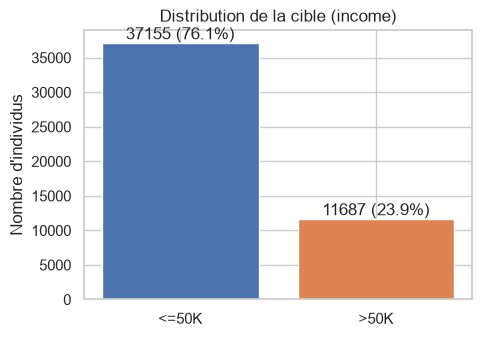

In [7]:
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df["income"].value_counts()
ax.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452"])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v} ({v/len(df):.1%})", ha="center", va="bottom")
ax.set_title("Distribution de la cible (income)")
ax.set_ylabel("Nombre d'individus")
savefig("01_target"); plt.show()

La cible est **déséquilibrée** : environ 24 % de >50K contre 76 % de ≤50K. Conséquences :
- l'accuracy est trompeuse, d'où l'utilisation de F1, ROC-AUC et PR-AUC ;
- on utilisera une **validation croisée stratifiée** ;
- on testera la **pondération des classes** (`class_weight="balanced"`) et l'**ajustement du seuil de décision**.

### 3.2 Distributions des variables numériques

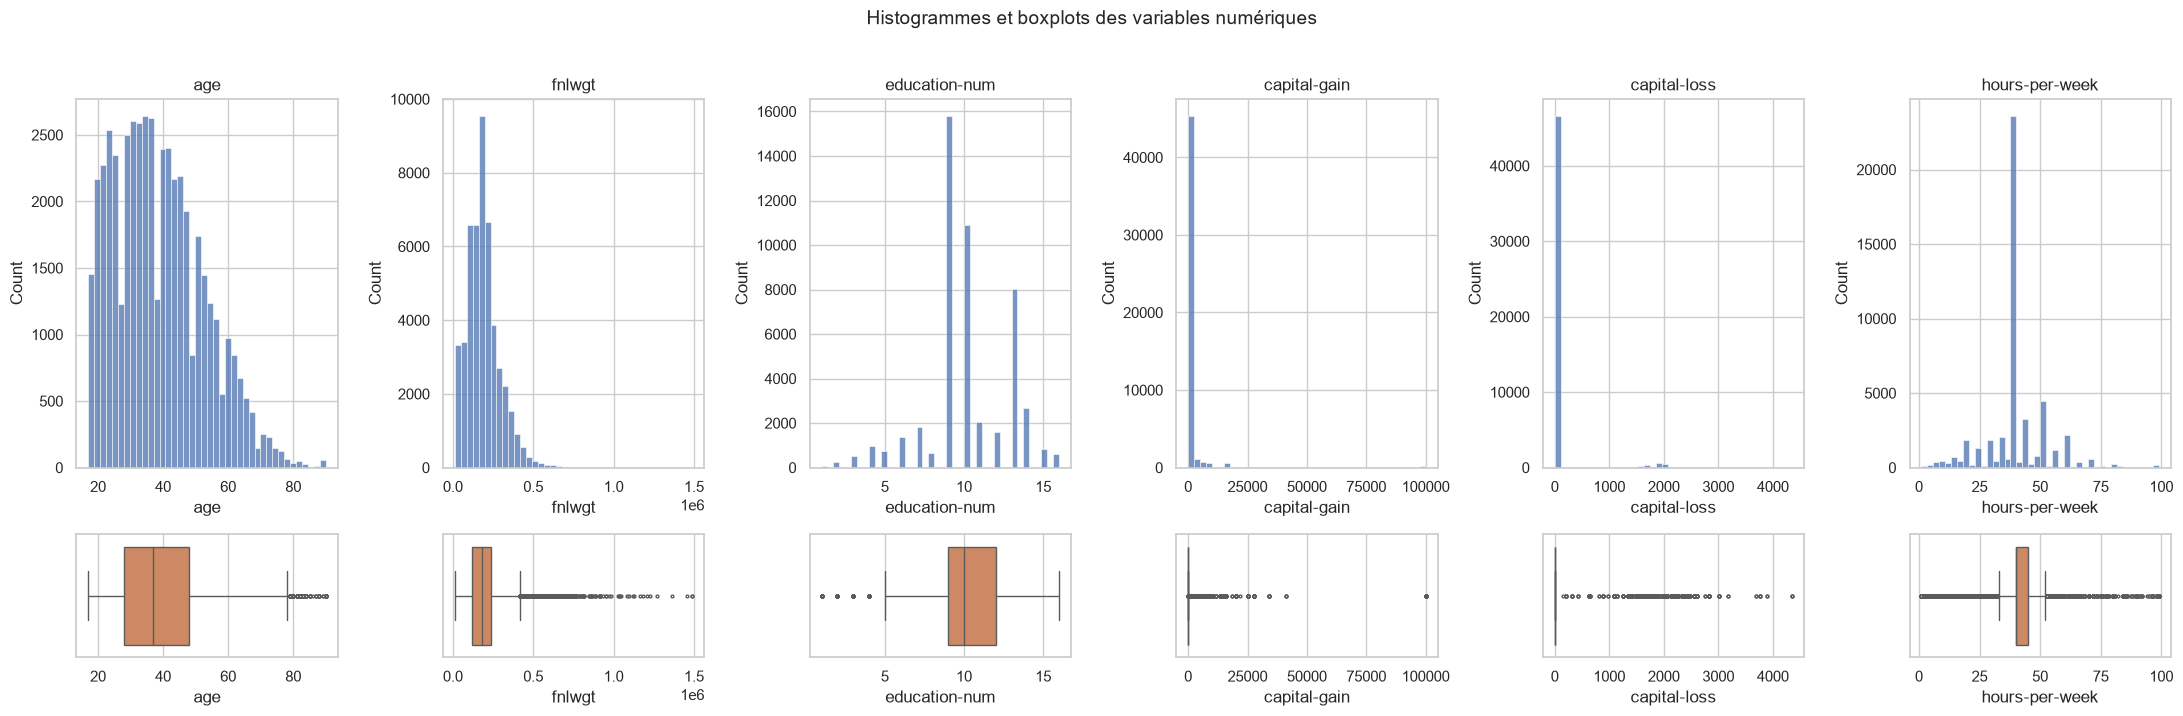

,skewness,kurtosis,% de zéros
age,0.56,-0.18,0.00
fnlwgt,1.44,6.06,0.00
education-num,-0.32,0.63,0.00
capital-gain,11.89,152.69,91.74
capital-loss,4.57,20.01,95.33
hours-per-week,0.24,2.95,0.00


In [8]:
fig, axes = plt.subplots(2, 6, figsize=(22, 7), gridspec_kw={"height_ratios": [3, 1]})
for i, c in enumerate(NUM_COLS):
    sns.histplot(df[c], bins=40, ax=axes[0, i], color="#4C72B0")
    axes[0, i].set_title(c)
    sns.boxplot(x=df[c], ax=axes[1, i], color="#DD8452", fliersize=2)
plt.suptitle("Histogrammes et boxplots des variables numériques", y=1.02, fontsize=14)
plt.tight_layout(); savefig("02_num_distributions"); plt.show()

pd.DataFrame({"skewness": df[NUM_COLS].skew(), "kurtosis": df[NUM_COLS].kurt(),
              "% de zéros": (df[NUM_COLS] == 0).mean() * 100}).round(2)

**Observations :**
- **age** : légèrement asymétrique à droite (population active jeune, peu de plus de 70 ans) ; valeur maximale 90.
- **fnlwgt** : très asymétrique. C'est un **poids de sondage**, pas une caractéristique de l'individu.
- **education-num** : discrète (1–16), avec des pics à 9 (HS-grad), 10 (Some-college) et 13 (Bachelors).
- **capital-gain / capital-loss** : **plus de 90 % de zéros** et une queue extrêmement longue (skewness très élevée). Une transformation (log) et/ou une binarisation sont nécessaires.
- **hours-per-week** : fortement concentré sur 40 h, avec des valeurs extrêmes (1 h, 99 h) visibles dans le boxplot.

### 3.3 Distributions des variables catégorielles

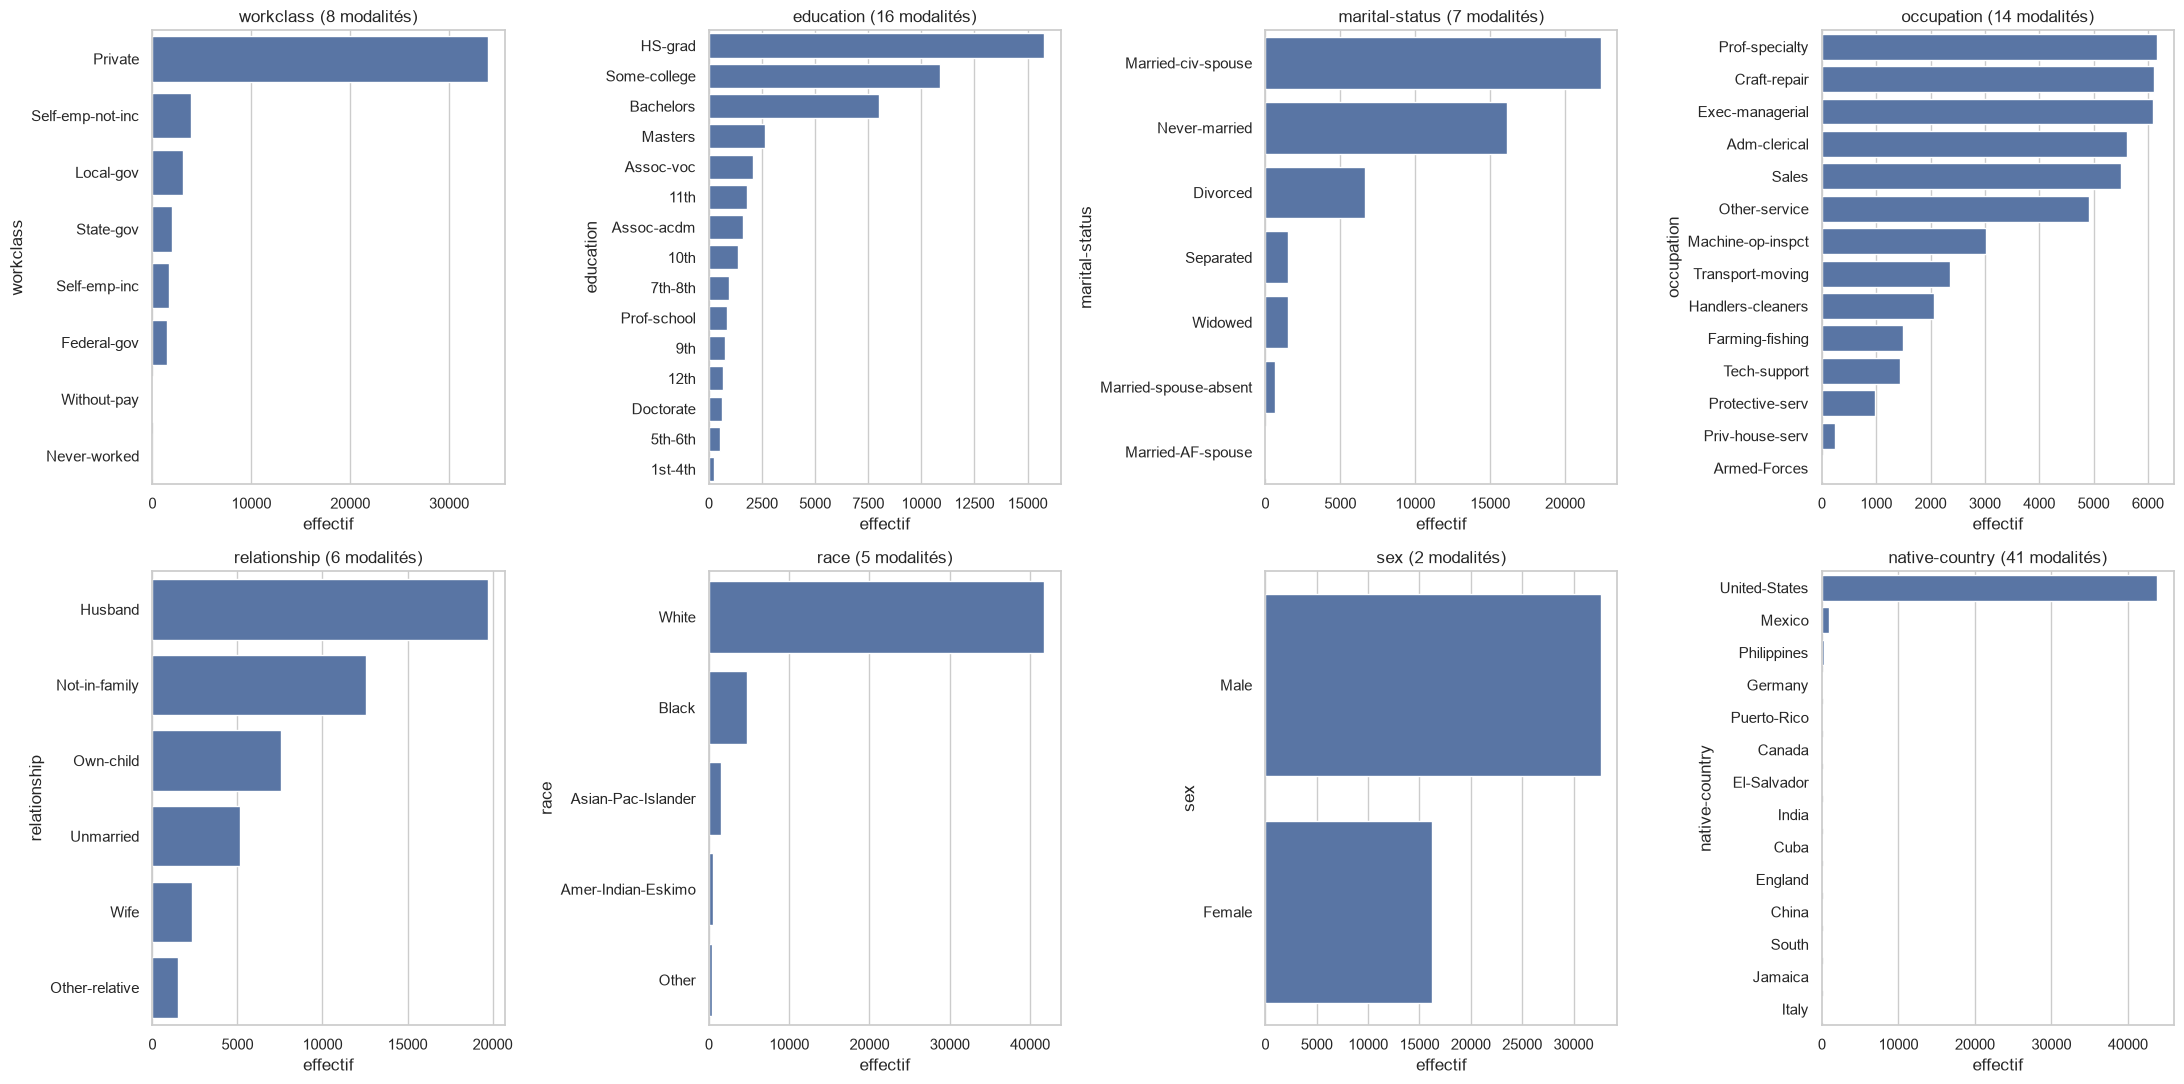

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
for ax, c in zip(axes.ravel(), CAT_COLS):
    vc = df[c].value_counts(dropna=False).head(15)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, color="#4C72B0")
    ax.set_title(f"{c} ({df[c].nunique()} modalités)")
    ax.set_xlabel("effectif")
plt.tight_layout(); savefig("03_cat_distributions"); plt.show()

In [10]:
# Modalités rares (< 0,5 % des observations)
for c in CAT_COLS:
    freq = df[c].value_counts(normalize=True)
    rare = freq[freq < 0.005]
    if len(rare):
        print(f"{c:15s}: {len(rare)} modalités rares -> {list(rare.index[:8])}{' ...' if len(rare) > 8 else ''}")

workclass      : 2 modalités rares -> ['Without-pay', 'Never-worked']
education      : 1 modalités rares -> ['Preschool']
marital-status : 1 modalités rares -> ['Married-AF-spouse']
occupation     : 1 modalités rares -> ['Armed-Forces']
native-country : 38 modalités rares -> ['Germany', 'Puerto-Rico', 'Canada', 'El-Salvador', 'India', 'Cuba', 'England', 'China'] ...


**Observations :**
- **native-country** : 41 modalités dont ~90 % `United-States`, avec énormément de modalités rares. Un encodage one-hot direct créerait ~40 colonnes quasi vides. Il faudra **regrouper** les pays.
- **workclass** : `Without-pay` et `Never-worked` ne comptent que quelques dizaines d'individus.
- **occupation** : `Armed-Forces` est très rare (15 individus).
- **marital-status** : `Married-AF-spouse` est rare (37 individus) et sémantiquement identique à `Married-civ-spouse`.
- **race** : dominée par `White` (~85 %).

### 3.4 Relations avec la cible

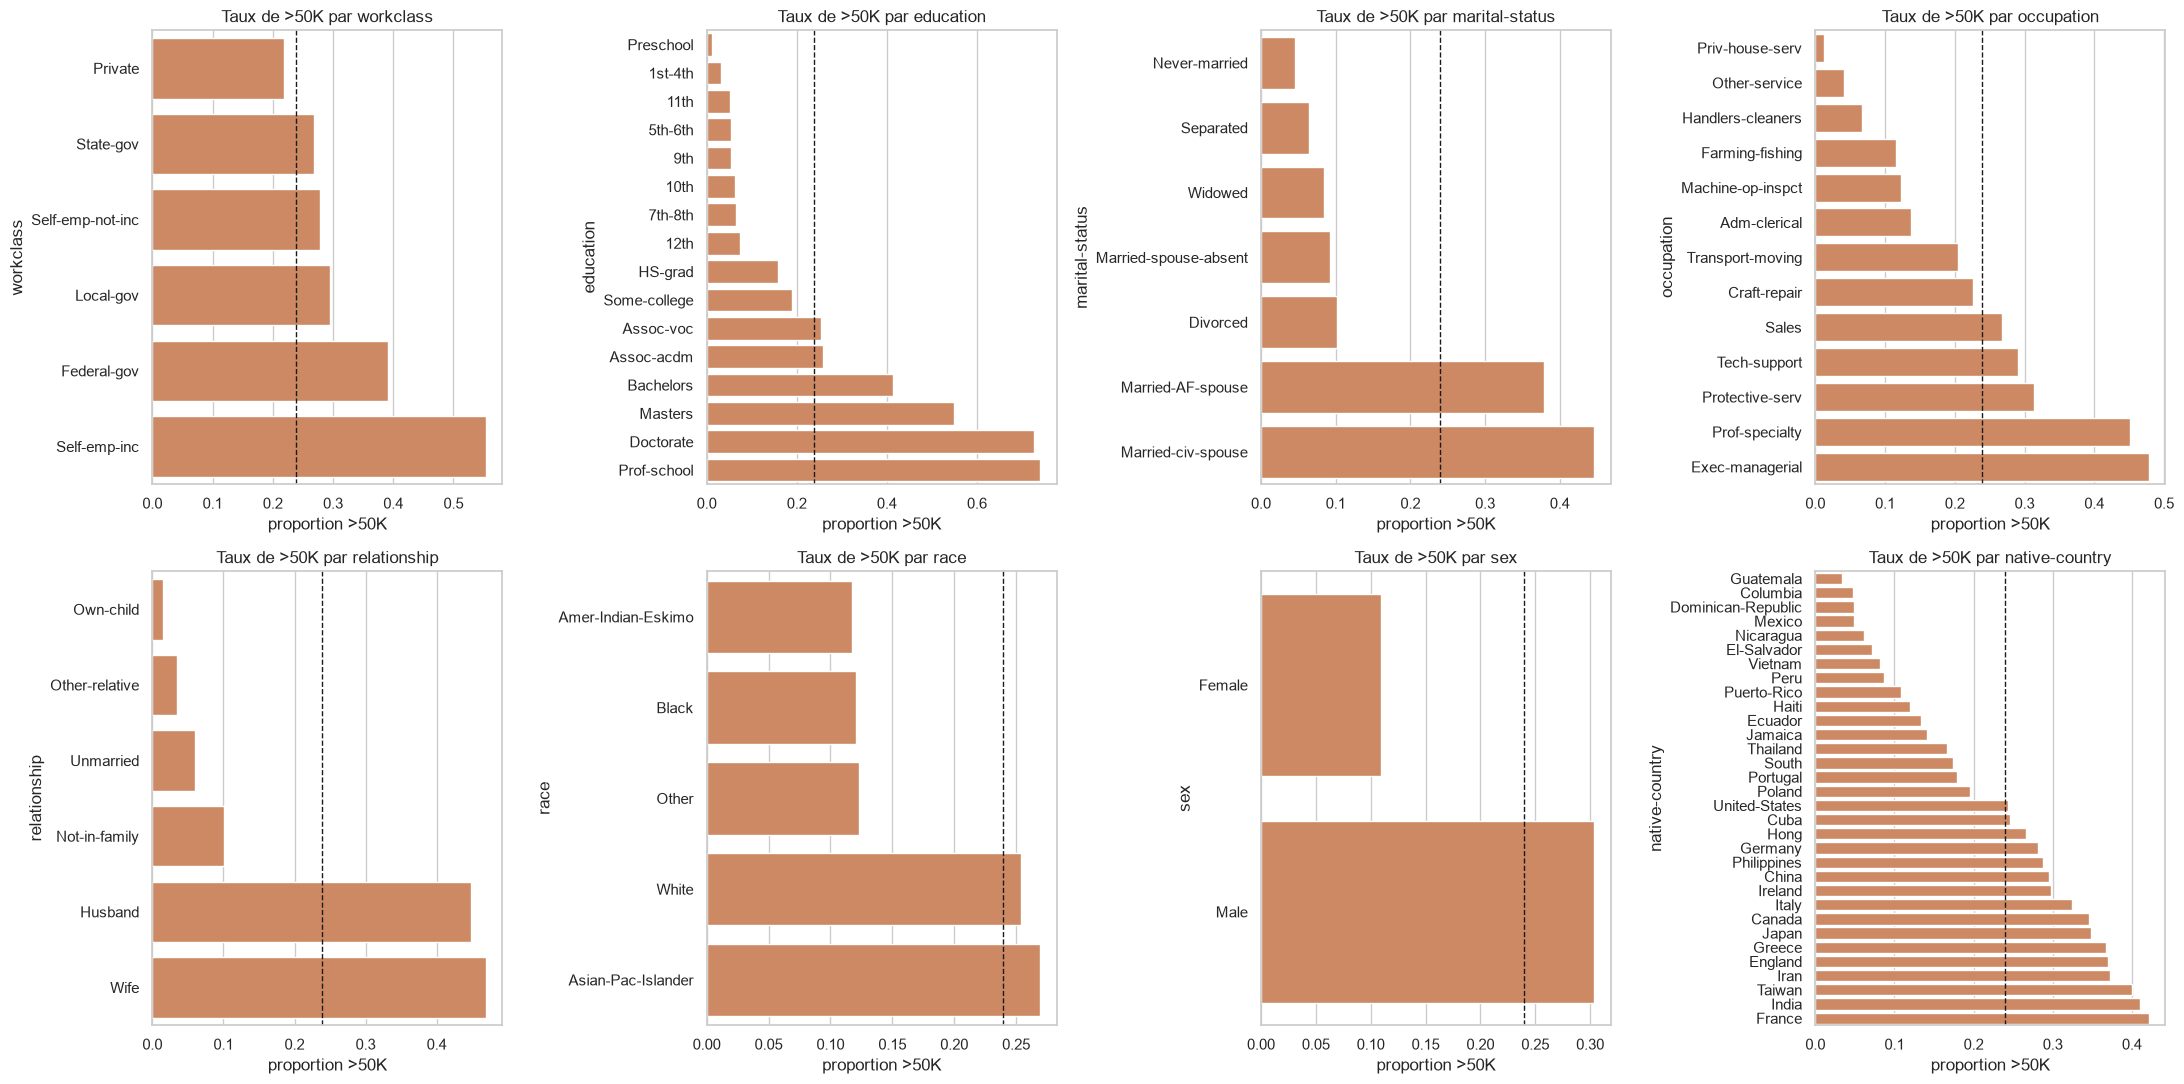

In [11]:
df["y"] = (df["income"] == ">50K").astype(int)

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
for ax, c in zip(axes.ravel(), CAT_COLS):
    rate = df.groupby(c)["y"].agg(["mean", "size"]).sort_values("mean")
    rate = rate[rate["size"] >= 30]            # on masque les modalités trop petites
    sns.barplot(x=rate["mean"], y=rate.index, ax=ax, color="#DD8452")
    ax.axvline(df["y"].mean(), ls="--", c="k", lw=1)
    ax.set_title(f"Taux de >50K par {c}")
    ax.set_xlabel("proportion >50K")
plt.tight_layout(); savefig("04_income_rate_by_cat"); plt.show()

**Tendances** (la ligne pointillée représente le taux moyen de 24 %) :
- **marital-status / relationship** : les personnes mariées (`Married-civ-spouse`, `Husband`, `Wife`) ont un taux de >50K de ~45 %, contre moins de 10 % pour les célibataires ou `Own-child`. C'est le facteur le plus discriminant.
- **education** : relation monotone, de <5 % sans diplôme à ~75 % pour `Doctorate` / `Prof-school`.
- **occupation** : `Exec-managerial` et `Prof-specialty` dépassent 45 %, contre <5 % pour `Priv-house-serv` et `Other-service`.
- **workclass** : `Self-emp-inc` (indépendants incorporés) a le taux le plus élevé.
- **sex** : les hommes ont un taux ~3× supérieur à celui des femmes (biais sociétal de 1994).

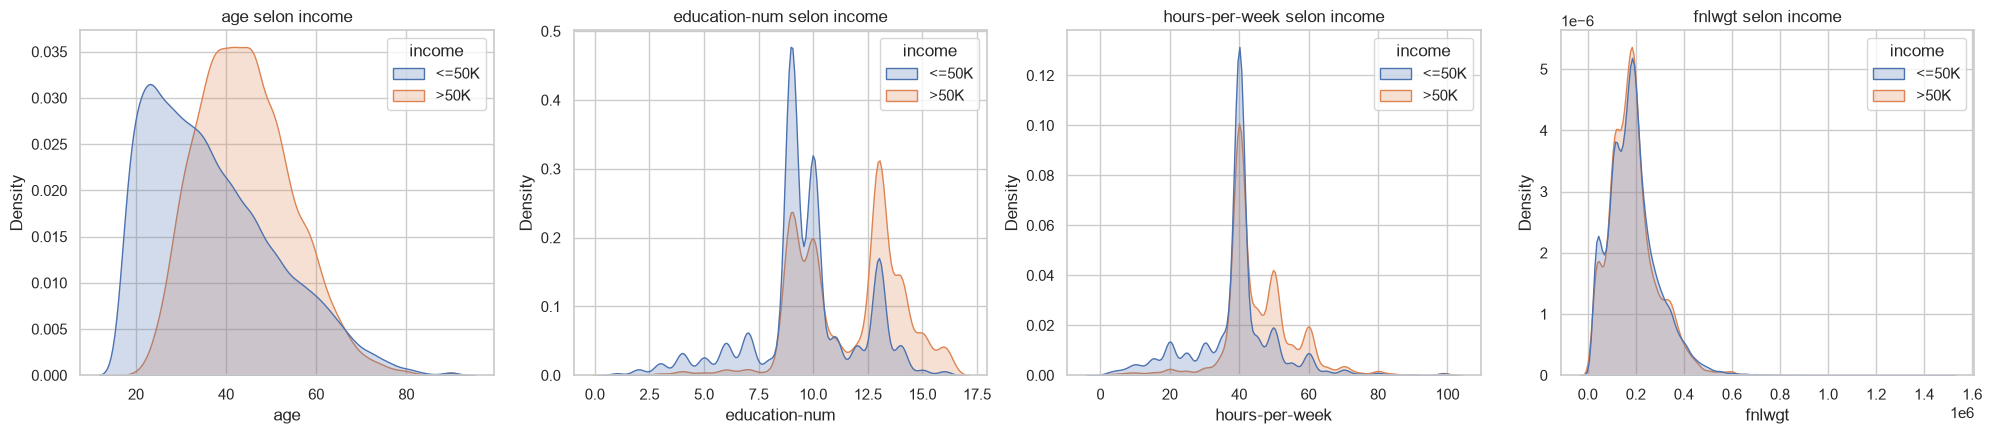

,variable,médiane <=50K,médiane >50K,p-value Mann-Whitney
0,age,34.0,43.0,0.000000e+00
1,fnlwgt,178811.0,176729.0,1.896909e-01
2,education-num,9.0,12.0,0.000000e+00
3,capital-gain,0.0,0.0,0.000000e+00
4,capital-loss,0.0,0.0,5.176444e-205
5,hours-per-week,40.0,40.0,0.000000e+00


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, c in zip(axes, ["age", "education-num", "hours-per-week", "fnlwgt"]):
    sns.kdeplot(data=df, x=c, hue="income", common_norm=False, fill=True, ax=ax)
    ax.set_title(f"{c} selon income")
plt.tight_layout(); savefig("05_num_vs_income"); plt.show()

# Test de Mann-Whitney : les distributions diffèrent-elles entre les deux classes ?
rows = []
for c in NUM_COLS:
    a, b = df.loc[df.y == 0, c], df.loc[df.y == 1, c]
    rows.append([c, a.median(), b.median(), stats.mannwhitneyu(a, b).pvalue])
pd.DataFrame(rows, columns=["variable", "médiane <=50K", "médiane >50K", "p-value Mann-Whitney"])

- Les individus >50K sont **plus âgés** (pic vers 40–50 ans), **plus diplômés** et **travaillent plus d'heures**.
- **fnlwgt** a une distribution quasi identique dans les deux classes : ce poids de sondage n'apporte pas d'information sur le revenu d'un individu. La p-value peut être significative à cause de la grande taille de l'échantillon, mais l'écart de médianes est négligeable.

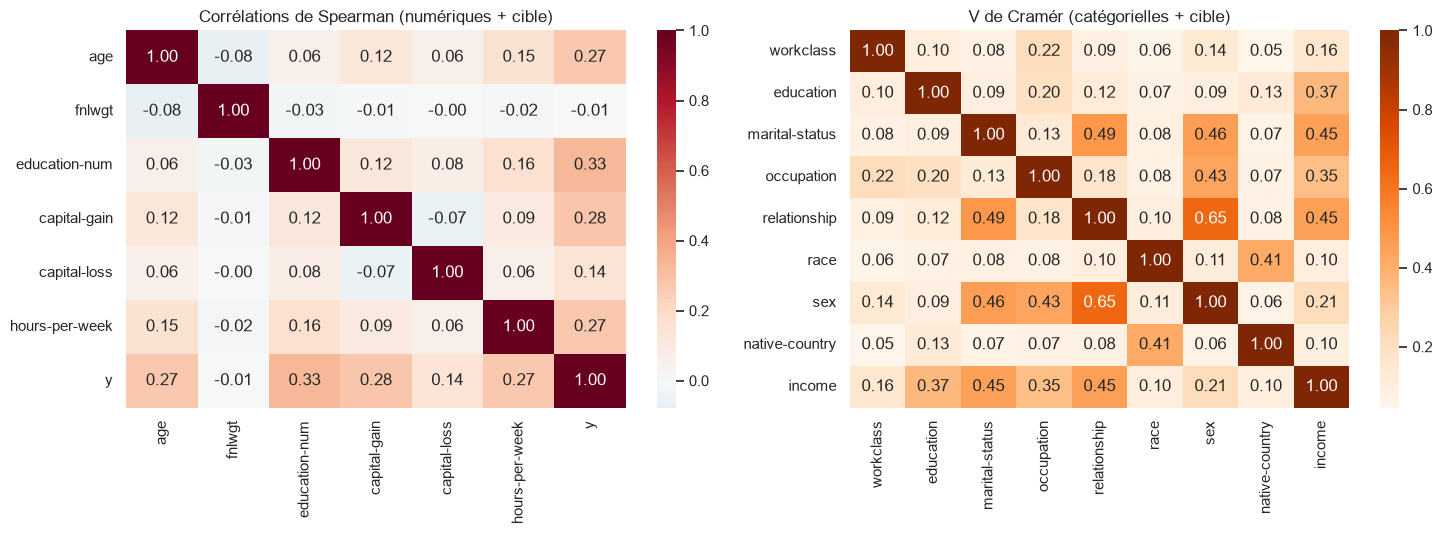

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
corr = df[NUM_COLS + ["y"]].corr(method="spearman")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Corrélations de Spearman (numériques + cible)")

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

cv_cols = CAT_COLS + ["income"]
cv = pd.DataFrame([[cramers_v(df[a], df[b]) for b in cv_cols] for a in cv_cols],
                  index=cv_cols, columns=cv_cols)
sns.heatmap(cv, annot=True, fmt=".2f", cmap="Oranges", ax=axes[1])
axes[1].set_title("V de Cramér (catégorielles + cible)")
plt.tight_layout(); savefig("06_correlations"); plt.show()

**Lecture :**
- Aucune corrélation linéaire forte entre variables numériques, donc pas de multicolinéarité problématique.
- `education` ↔ `education-num` : V de Cramér = **1,00**. Ce sont **deux codages de la même information** (voir 3.5).
- `relationship` ↔ `marital-status` et `relationship` ↔ `sex` : associations très fortes (`Husband` implique homme et marié). Il y a de la redondance, mais `relationship` contient aussi une information propre (`Own-child`, `Unmarried`).
- Les variables les plus liées à la cible sont `relationship`, `marital-status`, `education`/`education-num` et `occupation`. `fnlwgt` a une corrélation quasi nulle avec la cible.

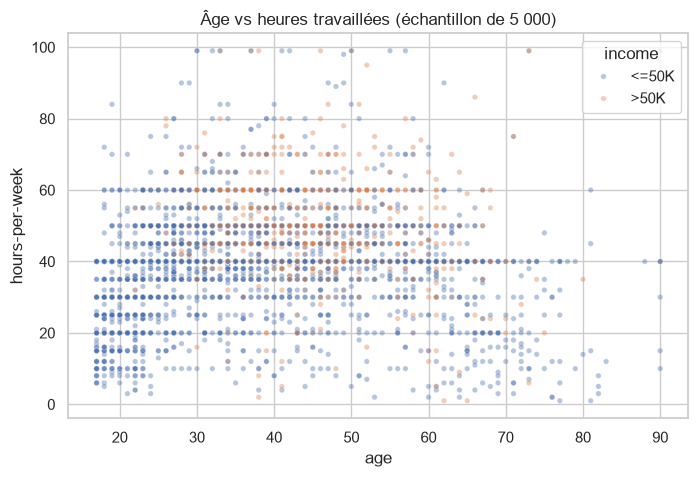

education-num,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
income,,,,,,,,,,,,,,,,
<=50K,0.988,0.968,0.947,0.935,0.946,0.937,0.949,0.927,0.841,0.81,0.747,0.742,0.587,0.451,0.26,0.274
>50K,0.012,0.032,0.053,0.065,0.054,0.063,0.051,0.073,0.159,0.19,0.253,0.258,0.413,0.549,0.74,0.726


In [14]:
sample = df.sample(5000, random_state=RANDOM_STATE)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="age", y="hours-per-week", hue="income", alpha=0.4, s=15)
plt.title("Âge vs heures travaillées (échantillon de 5 000)")
savefig("07_age_hours"); plt.show()

pd.crosstab(df["education-num"], df["income"], normalize="index").round(3).T

### 3.5 Détection des anomalies et problèmes de qualité

#### a) Valeurs manquantes

In [15]:
miss = df.isna().sum()
miss = pd.DataFrame({"n_missing": miss, "% missing": (miss / len(df) * 100).round(2)})
display(miss[miss.n_missing > 0])

# Co-occurrence des valeurs manquantes
print("workclass NaN & occupation NaN :", (df.workclass.isna() & df.occupation.isna()).sum())
print("occupation NaN seul            :", (df.occupation.isna() & df.workclass.notna()).sum())
print("-> workclass de ces lignes      :", df.loc[df.occupation.isna() & df.workclass.notna(), "workclass"].unique())
print("Lignes avec au moins un NaN     :", df.isna().any(axis=1).sum(),
      f"({df.isna().any(axis=1).mean():.1%})")

,n_missing,% missing
workclass,2799,5.73
occupation,2809,5.75
native-country,857,1.75


workclass NaN & occupation NaN : 2799
occupation NaN seul            : 10
-> workclass de ces lignes      : <StringArray>
['Never-worked']
Length: 1, dtype: str
Lignes avec au moins un NaN     : 3620 (7.4%)


,taux_50K,age_moyen,heures_moy,effectif
occupation renseignée,0.248,38.557,40.948,46033
occupation manquante,0.094,40.069,31.802,2809


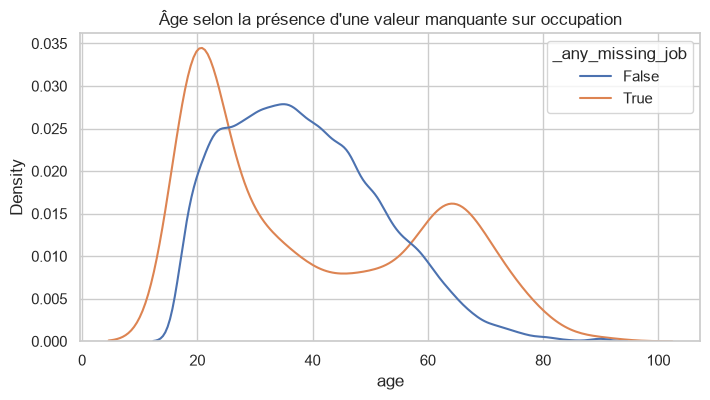

In [16]:
# Les valeurs manquantes sont-elles aléatoires ? (MCAR vs MNAR/MAR)
df["_any_missing_job"] = df["occupation"].isna()
comp = df.groupby("_any_missing_job").agg(
    taux_50K=("y", "mean"), age_moyen=("age", "mean"),
    heures_moy=("hours-per-week", "mean"), effectif=("y", "size")).round(3)
comp.index = ["occupation renseignée", "occupation manquante"]
display(comp)

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=df, x="age", hue="_any_missing_job", common_norm=False, ax=ax)
ax.set_title("Âge selon la présence d'une valeur manquante sur occupation")
savefig("08_missing_age"); plt.show()
df = df.drop(columns="_any_missing_job")

**Analyse des valeurs manquantes :**
- Elles ne concernent que `workclass` (~5,7 %), `occupation` (~5,8 %) et `native-country` (~1,8 %). Environ 7,4 % des lignes sont touchées.
- `workclass` et `occupation` sont **manquantes simultanément** dans quasiment tous les cas. Les seules exceptions sont les individus `Never-worked` : ils n'ont **logiquement pas de profession**. Il s'agit d'une **valeur manquante structurelle**, pas d'une erreur.
- Les individus sans profession renseignée ont un **taux de >50K environ 2,5 fois plus faible**. Ils sont **surreprésentés aux âges extrêmes** (≈ 38 % ont 25 ans ou moins et ≈ 25 % plus de 60 ans, contre 19 % et 6 % pour les autres : étudiants, retraités) et **travaillent moins d'heures** (≈ 32 h contre 41 h). Les valeurs manquantes **ne sont donc pas aléatoires (pas MCAR)**. Le fait d'être manquant est **informatif** (personnes hors du marché du travail).

La stratégie retenue et sa justification sont présentées en section 4.

#### b) Doublons

In [17]:
dup = df.drop(columns="y").duplicated(keep="first")
print("Doublons exacts :", dup.sum())
df[df.drop(columns="y").duplicated(keep=False)].sort_values(COLS).head(6)

Doublons exacts : 29


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,split,y
36461,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K,test,0
48521,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K,test,0
17673,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K,train,0
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K,train,0
6990,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K,train,0
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K,train,0


Quelques dizaines de lignes strictement identiques, **y compris sur `fnlwgt`** (poids de sondage à 6 chiffres). Une coïncidence est très improbable : ce sont vraisemblablement des doublons de saisie. Ils sont peu nombreux mais seront supprimés pour ne pas sur-pondérer ces individus et ne pas avoir la même personne à la fois dans les plis d'apprentissage et de validation.

#### c) Redondance `education` / `education-num`

In [18]:
print("Nombre de valeurs education-num par modalité d'education :",
      df.groupby("education")["education-num"].nunique().unique())
df.groupby("education")["education-num"].first().sort_values().to_frame().T

Nombre de valeurs education-num par modalité d'education : [1]


education,Preschool,1st-4th,5th-6th,7th-8th,9th,10th,11th,12th,HS-grad,Some-college,Assoc-voc,Assoc-acdm,Bachelors,Masters,Prof-school,Doctorate
education-num,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16


Chaque modalité d'`education` correspond à **une et une seule** valeur d'`education-num` : les deux colonnes sont redondantes. On conservera `education-num`, qui est **ordinale** (l'ordre des diplômes est respecté). Cela évite 16 colonnes one-hot et préserve la relation monotone observée avec le revenu.

#### d) Valeurs aberrantes (outliers)

In [19]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

out = pd.DataFrame({
    "outliers IQR": {c: iqr_outliers(df[c]) for c in NUM_COLS},
    "outliers |z|>3": {c: (np.abs(stats.zscore(df[c])) > 3).sum() for c in NUM_COLS},
    "min": df[NUM_COLS].min(), "max": df[NUM_COLS].max()})
out

,outliers IQR,outliers |z|>3,min,max
age,216,186,17,90
fnlwgt,1453,506,12285,1490400
education-num,1794,330,1,16
capital-gain,4035,331,0,99999
capital-loss,2282,2216,0,4356
hours-per-week,13496,681,1,99


In [20]:
print("capital-gain = 99999 :", (df["capital-gain"] == 99999).sum(),
      "| taux >50K parmi eux :", round(df.loc[df["capital-gain"] == 99999, "y"].mean(), 3))
print("Valeur suivante max de capital-gain :", df.loc[df["capital-gain"] < 99999, "capital-gain"].max())
print("hours-per-week = 99 :", (df["hours-per-week"] == 99).sum(),
      "| hours-per-week < 5 :", (df["hours-per-week"] < 5).sum())
print("age = 90 :", (df["age"] == 90).sum())
print("Heures < 20 chez les plus de 65 ans :", ((df.age > 65) & (df["hours-per-week"] < 20)).sum())

capital-gain = 99999 : 244 | taux >50K parmi eux : 1.0
Valeur suivante max de capital-gain : 41310
hours-per-week = 99 : 137 | hours-per-week < 5 : 223
age = 90 : 55
Heures < 20 chez les plus de 65 ans : 511


**Analyse des outliers :** le choix du traitement dépend de la **nature** de l'outlier, pas seulement de sa détection statistique.
- **capital-gain = 99999** : valeur **plafonnée (*top-coding*)** du recensement. Aucune valeur entre ~41 000 et 99 999 n'existe. Ces individus sont presque tous >50K : c'est une **information réelle et très prédictive**, à ne pas supprimer.
- **capital-gain / capital-loss** : la règle IQR marque *tous* les non-zéros comme outliers (Q1 = Q3 = 0), ce qui n'a pas de sens ici. Le problème vient de la **forme de la distribution** (zéro-inflation et longue queue), pas d'erreurs.
- **hours-per-week** : 1 h ou 99 h par semaine sont extrêmes mais **plausibles** (temps très partiel, agriculteurs, indépendants). Ce ne sont pas des erreurs, mais ces valeurs peuvent peser fortement sur les modèles basés sur des distances (K-Means, KNN) et sur la régression logistique.
- **age = 90** : probablement aussi un plafond (peu de 89 ans mais un pic à 90). L'effectif est faible et l'âge est plausible, donc on garde.
- **fnlwgt** : outliers nombreux, mais la variable sera retirée (poids d'échantillonnage).

#### e) Incohérences logiques

In [21]:
display(pd.crosstab(df["relationship"], df["sex"]))
incoh = df[((df.relationship == "Husband") & (df.sex == "Female")) |
           ((df.relationship == "Wife") & (df.sex == "Male"))]
print("Husband/Female ou Wife/Male :", len(incoh))
print("Married & relationship Unmarried/Own-child... :",
      ((df["marital-status"].str.startswith("Married-civ")) & (df.relationship.isin(["Unmarried"]))).sum())
print("Never-worked avec heures > 0 :", ((df.workclass == "Never-worked") & (df["hours-per-week"] > 0)).sum())

sex,Female,Male
relationship,,
Husband,1,19715
Not-in-family,5870,6713
Other-relative,689,817
Own-child,3376,4205
Unmarried,3928,1197
Wife,2328,3


Husband/Female ou Wife/Male : 4
Married & relationship Unmarried/Own-child... : 0
Never-worked avec heures > 0 : 10


- Quelques individus sont `Husband` + `Female` ou `Wife` + `Male`. Ce sont des incohérences sémantiques (erreur de saisie, ou couples de même sexe codés de façon atypique en 1994). Elles sont très rares et **on ne peut pas savoir quelle colonne est fausse**. On les **supprime** plutôt que de deviner une correction.
- Les `Never-worked` déclarent des heures travaillées > 0. C'est une incohérence connue du dataset, mais elle ne concerne que ~10 personnes et l'information `Never-worked` reste exploitable. On les regroupe avec `Without-pay` (voir 4).

### 3.6 Synthèse de l'exploration

| Problème identifié | Variable(s) | Traitement prévu |
|---|---|---|
| Format de cible incohérent (`>50K.`) | income | Uniformisation (fait) |
| Valeurs manquantes codées `?`, non aléatoires | workclass, occupation, native-country | Modalité explicite `Unknown` / `None` |
| Doublons exacts | toutes | Suppression |
| Incohérences Husband/Female | relationship, sex | Suppression |
| Redondance | education ↔ education-num | Garder `education-num` (ordinale) |
| Variable non pertinente | fnlwgt | Suppression (poids de sondage) |
| Distribution zéro-inflée, longue queue | capital-gain, capital-loss | log1p + indicateurs binaires |
| Valeurs extrêmes plausibles | hours-per-week | Winsorisation (1er–99e percentile du train) |
| Modalités rares / haute cardinalité | native-country, workclass, occupation, marital-status | Regroupements |
| Cible déséquilibrée (76/24) | income | Stratification, F1/AUC, class_weight, seuil |

---
## 4. Data Preparation

Chaque étape est accompagnée de sa justification. On travaille sur une copie `data` pour garder `df` comme référence brute.

### 4.1 Suppression des doublons et des incohérences

In [22]:
data = df.copy()
n0 = len(data)
data = data.drop_duplicates(subset=COLS + ["split"]).reset_index(drop=True)
n1 = len(data)
bad = ((data.relationship == "Husband") & (data.sex == "Female")) | \
      ((data.relationship == "Wife") & (data.sex == "Male"))
data = data[~bad].reset_index(drop=True)
print(f"Doublons supprimés : {n0 - n1} | incohérences supprimées : {bad.sum()} | lignes restantes : {len(data)}")

Doublons supprimés : 29 | incohérences supprimées : 4 | lignes restantes : 48809


### 4.2 Traitement des valeurs manquantes

**Méthodes envisagées et choix :**

| Méthode | Avantage | Inconvénient ici | Retenue ? |
|---|---|---|---|
| Suppression des lignes | Simple | Perte d'environ 7 % des données, et **biais** : on retire surtout des individus ≤50K hors emploi, ce qui fausse la distribution | ❌ |
| Imputation par le mode (`Private`, `Prof-specialty`, `United-States`) | Simple | Attribue une profession qualifiée (taux de >50K élevé) à des personnes sans emploi et **détruit l'information** « hors marché du travail » | ❌ |
| Imputation KNN / par modèle | Exploite les corrélations | Suppose des données MAR, alors qu'ici l'absence **est** l'information. Coûteux, et l'invention d'une profession reste artificielle | ❌ |
| **Modalité explicite `Unknown`** | Conserve toutes les lignes, **préserve le signal** de l'absence, sans hypothèse forte | Ajoute une modalité | ✅ |

Cas particulier : pour les `Never-worked`, l'occupation manquante est **logique**. On lui donne la modalité `None` (aucune profession) plutôt qu'`Unknown`.

In [23]:
data.loc[data.workclass == "Never-worked", "occupation"] = "None"
for c in ["workclass", "occupation", "native-country"]:
    data[c] = data[c].fillna("Unknown")
print("NaN restants :", data[COLS].isna().sum().sum())
data.groupby("occupation")["y"].agg(["mean", "size"]).loc[["Unknown", "None"]].round(3)

NaN restants : 0


,mean,size
occupation,,
Unknown,0.095,2799
None,0.000,10


### 4.3 Regroupement des modalités rares et réduction de cardinalité

**Pourquoi ?** Des modalités de quelques dizaines d'individus produisent des colonnes one-hot quasi vides. Les modèles en estiment mal l'effet (variance élevée, sur-apprentissage), et elles alourdissent inutilement la distance euclidienne en clustering. Les regroupements sont faits **selon le sens métier** et vérifiés avec le taux de >50K.

- **workclass** : `Without-pay` + `Never-worked` → `No-income`.
- **marital-status** : `Married-civ-spouse` + `Married-AF-spouse` → `Married` (même situation, conjoint militaire ou civil). `Separated` + `Married-spouse-absent` + `Divorced` → `Separated/Divorced` (foyer à un seul revenu, taux de >50K proches). `Never-married` et `Widowed` restent inchangés.
- **occupation** : `Armed-Forces` (15 individus) → `Protective-serv`, le métier le plus proche (sécurité / défense).
- **native-country** : 41 pays → **6 régions** (United-States, Latin-America, Asia, Europe, Other, Unknown). On garde ainsi l'information géographique et culturelle sans 40 colonnes creuses.

In [24]:
data["workclass"] = data["workclass"].replace({"Without-pay": "No-income", "Never-worked": "No-income"})

data["marital-status"] = data["marital-status"].replace({
    "Married-civ-spouse": "Married", "Married-AF-spouse": "Married",
    "Separated": "Separated/Divorced", "Married-spouse-absent": "Separated/Divorced",
    "Divorced": "Separated/Divorced"})

data["occupation"] = data["occupation"].replace({"Armed-Forces": "Protective-serv"})

REGION = {
    "United-States": "United-States",
    # Amérique latine & Caraïbes
    "Mexico": "Latin-America", "Puerto-Rico": "Latin-America", "El-Salvador": "Latin-America",
    "Cuba": "Latin-America", "Jamaica": "Latin-America", "Dominican-Republic": "Latin-America",
    "Guatemala": "Latin-America", "Columbia": "Latin-America", "Haiti": "Latin-America",
    "Nicaragua": "Latin-America", "Peru": "Latin-America", "Ecuador": "Latin-America",
    "Trinadad&Tobago": "Latin-America", "Honduras": "Latin-America",
    # Asie
    "Philippines": "Asia", "India": "Asia", "China": "Asia", "Japan": "Asia", "Vietnam": "Asia",
    "Taiwan": "Asia", "Iran": "Asia", "Hong": "Asia", "Thailand": "Asia", "Cambodia": "Asia",
    "Laos": "Asia",
    # Europe
    "Germany": "Europe", "England": "Europe", "Italy": "Europe", "Poland": "Europe",
    "Portugal": "Europe", "Greece": "Europe", "France": "Europe", "Ireland": "Europe",
    "Yugoslavia": "Europe", "Hungary": "Europe", "Scotland": "Europe", "Holand-Netherlands": "Europe",
    # Autres / ambigus ("South" : pays non identifiable)
    "Canada": "Other", "South": "Other", "Outlying-US(Guam-USVI-etc)": "Other",
    "Unknown": "Unknown",
}
data["region"] = data["native-country"].map(REGION)
assert data["region"].notna().all(), data.loc[data.region.isna(), "native-country"].unique()

for c in ["workclass", "marital-status", "occupation", "region"]:
    print(data.groupby(c)["y"].agg(taux_50K="mean", effectif="size").round(3).sort_values("taux_50K"), "\n")

                  taux_50K  effectif
workclass                           
No-income            0.065        31
Unknown              0.095      2799
Private              0.218     33876
State-gov            0.268      1981
Self-emp-not-inc     0.279      3861
Local-gov            0.296      3135
Federal-gov          0.392      1432
Self-emp-inc         0.554      1694 



                    taux_50K  effectif
marital-status                        
Never-married          0.046     16098
Widowed                0.084      1518
Separated/Divorced     0.094      8788
Married                0.446     22405 

                   taux_50K  effectif
occupation                           
None                  0.000        10
Priv-house-serv       0.012       240
Other-service         0.041      4919
Handlers-cleaners     0.067      2071
Unknown               0.095      2799
Farming-fishing       0.116      1487
Machine-op-inspct     0.123      3018
Adm-clerical          0.137      5608
Transport-moving      0.204      2355
Craft-repair          0.226      6107
Sales                 0.268      5502
Tech-support          0.291      1445
Protective-serv       0.314       998
Prof-specialty        0.451      6167
Exec-managerial       0.478      6083 

               taux_50K  effectif
region                           
Latin-America     0.080      2066
United-States 

Les regroupements sont cohérents : les modalités fusionnées ont des taux de >50K proches, et chaque nouvelle modalité a un effectif suffisant.

### 4.4 Traitement des outliers et transformation des distributions

**capital-gain / capital-loss.** On applique **`log1p(x) = log(1 + x)`**, qui gère les zéros (log1p(0) = 0) et comprime la longue queue sans supprimer d'individus. Le plafond 99999 est conservé (information réelle). On ajoute aussi des **indicateurs binaires** `has_capital_gain` / `has_capital_loss`, car le fait de posséder un capital est lui-même très discriminant.
*Alternatives écartées :* suppression (perte des individus les plus riches, donc d'une information clé), Box-Cox (impossible avec des zéros), standardisation seule (n'agit pas sur l'asymétrie).

**hours-per-week.** On applique une **winsorisation** au 1er et au 99e percentile **calculés sur le train uniquement** (pas de fuite d'information du test). Les valeurs sont plausibles, donc on ne supprime personne, mais on borne leur influence sur K-Means, KNN et la régression logistique. Cela ne concerne qu'environ 1,6 % des valeurs (bornes [8 h, 80 h]).

**age.** Asymétrie modérée, plage réaliste (17–90) : aucune transformation.

**fnlwgt.** Supprimé : c'est un **poids de sondage** (combien de personnes la ligne représente dans la population américaine), pas une caractéristique de la personne. Sa corrélation avec la cible est ~0. L'utiliser comme feature ajouterait du bruit.

Bornes de winsorisation hours-per-week (train) : [8.0, 80.0]
Valeurs modifiées : 773


,avant,après
capital-gain → log1p,11.89,3.11
capital-loss → log1p,4.57,4.30
hours-per-week → winsorisé,0.24,0.02


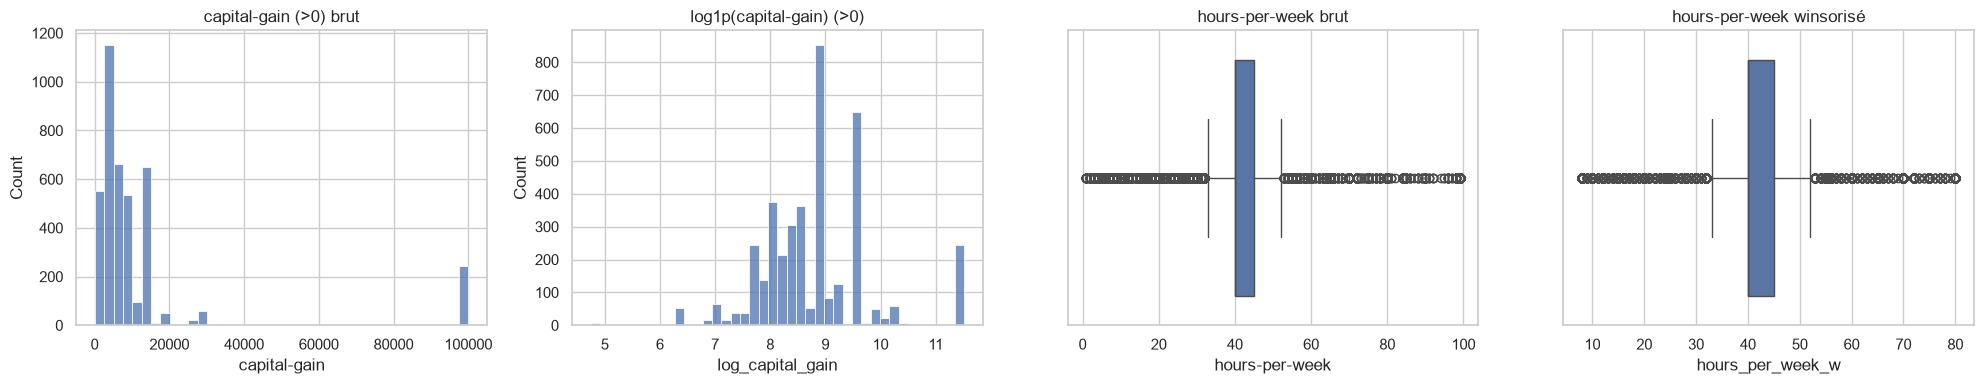

In [25]:
train_mask = data["split"] == "train"
lo, hi = data.loc[train_mask, "hours-per-week"].quantile([0.01, 0.99])
print(f"Bornes de winsorisation hours-per-week (train) : [{lo}, {hi}]")
print("Valeurs modifiées :", ((data["hours-per-week"] < lo) | (data["hours-per-week"] > hi)).sum())
data["hours_per_week_w"] = data["hours-per-week"].clip(lo, hi)

data["log_capital_gain"] = np.log1p(data["capital-gain"])
data["log_capital_loss"] = np.log1p(data["capital-loss"])
data["has_capital_gain"] = (data["capital-gain"] > 0).astype(int)
data["has_capital_loss"] = (data["capital-loss"] > 0).astype(int)

skew = pd.DataFrame({
    "avant": data[["capital-gain", "capital-loss", "hours-per-week"]].skew().values,
    "après": data[["log_capital_gain", "log_capital_loss", "hours_per_week_w"]].skew().values},
    index=["capital-gain → log1p", "capital-loss → log1p", "hours-per-week → winsorisé"]).round(2)
display(skew)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
sns.histplot(data.loc[data["capital-gain"] > 0, "capital-gain"], bins=40, ax=axes[0]); axes[0].set_title("capital-gain (>0) brut")
sns.histplot(data.loc[data["capital-gain"] > 0, "log_capital_gain"], bins=40, ax=axes[1]); axes[1].set_title("log1p(capital-gain) (>0)")
sns.boxplot(x=data["hours-per-week"], ax=axes[2]); axes[2].set_title("hours-per-week brut")
sns.boxplot(x=data["hours_per_week_w"], ax=axes[3]); axes[3].set_title("hours-per-week winsorisé")
plt.tight_layout(); savefig("09_transformations"); plt.show()

### 4.5 Feature engineering

| Nouvelle variable | Construction | Justification |
|---|---|---|
| `has_capital_gain`, `has_capital_loss` | capital > 0 | Posséder un capital est un marqueur de patrimoine, indépendamment du montant |
| `log_capital_gain`, `log_capital_loss` | log1p | Distribution exploitable par les modèles linéaires et les distances |
| `capital_net` | gain − loss | Solde financier global (utile pour l'interprétation) |
| `is_married` | marital-status = Married | Facteur le plus discriminant ; utile en binaire pour le clustering |
| `sex_male` | sex = Male | Encodage binaire (2 modalités) |
| `age_group` | tranches d'âge | Lecture métier des profils (cycle de vie), utilisée pour l'interprétation |
| `hours_category` | Part-time < 35 h ≤ Full-time ≤ 45 h < Overtime | Normes de temps de travail, pour l'interprétation |
| `education_level` | regroupement des diplômes | Lecture simplifiée des profils |
| `region` | pays → région | Réduction de cardinalité (4.3) |

*Remarque :* `age_group`, `hours_category` et `education_level` servent à **décrire** les segments. Pour les modèles, on garde les versions continues (`age`, `hours_per_week_w`, `education-num`), plus riches en information. Utiliser les deux en même temps serait redondant.

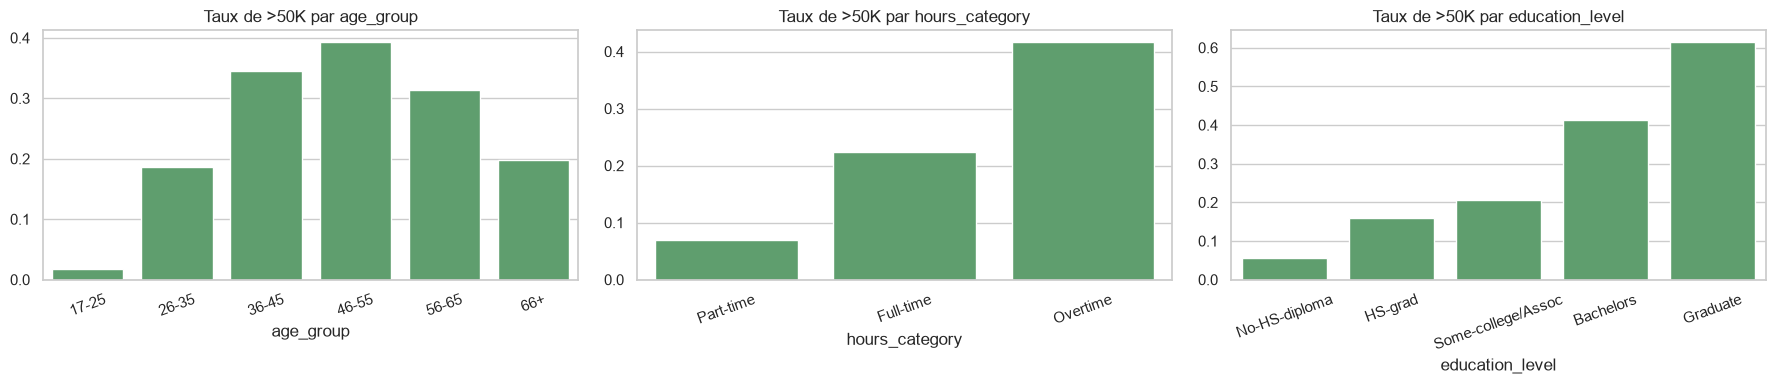

In [26]:
data["capital_net"] = data["capital-gain"] - data["capital-loss"]
data["is_married"] = (data["marital-status"] == "Married").astype(int)
data["sex_male"] = (data["sex"] == "Male").astype(int)
data["age_group"] = pd.cut(data["age"], bins=[16, 25, 35, 45, 55, 65, 91],
                           labels=["17-25", "26-35", "36-45", "46-55", "56-65", "66+"])
data["hours_category"] = pd.cut(data["hours-per-week"], bins=[0, 34, 45, 100],
                                labels=["Part-time", "Full-time", "Overtime"])
data["education_level"] = pd.cut(data["education-num"], bins=[0, 8, 9, 12, 13, 16],
                                 labels=["No-HS-diploma", "HS-grad", "Some-college/Assoc",
                                         "Bachelors", "Graduate"])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, c in zip(axes, ["age_group", "hours_category", "education_level"]):
    r = data.groupby(c, observed=True)["y"].mean()
    sns.barplot(x=r.index.astype(str), y=r.values, ax=ax, color="#55A868")
    ax.set_title(f"Taux de >50K par {c}"); ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); savefig("10_engineered_features"); plt.show()

Les features construites montrent des gradients nets : le taux de >50K culmine entre 46 et 55 ans, est ~4× plus élevé pour `Overtime` que pour `Part-time`, et croît fortement avec le niveau d'études.

### 4.6 Encodage des variables catégorielles

- **Binaires** (`sex`) : codage 0/1 (`sex_male`).
- **Ordinale** (`education`) : on utilise `education-num`, qui respecte l'ordre des diplômes.
- **Nominales** (`workclass`, `marital-status`, `occupation`, `relationship`, `race`, `region`) : **One-Hot Encoding**.
  - *Pourquoi pas le Label Encoding ?* Il imposerait un ordre artificiel (ex. `Sales` = 3 > `Tech-support` = 2). La régression logistique, KNN et K-Means interpréteraient ces nombres comme des distances ou des quantités.
  - *Pourquoi pas le Target Encoding ?* Après regroupement, la cardinalité est faible (≤ 15 modalités), donc le one-hot reste compact. Le target encoding ajouterait un risque de fuite de la cible.
- **Cible** : `income` → `y` ∈ {0, 1}.

### 4.7 Mise à l'échelle
La **standardisation** (`StandardScaler`, moyenne 0 et écart-type 1) est nécessaire pour les algorithmes basés sur des distances ou des coefficients (K-Means, KNN, régression logistique). Sans elle, `age` (17–90) écraserait les variables binaires (0/1). Elle est préférée au Min-Max, plus sensible aux valeurs extrêmes résiduelles.
**Elle n'est pas appliquée dans le fichier livré** : elle est intégrée dans des `Pipeline` scikit-learn et **ajustée sur le train uniquement**, pour éviter toute fuite de données vers le test. Les arbres de décision n'en ont pas besoin.

In [27]:
NUM_FEATURES = ["age", "education-num", "hours_per_week_w", "log_capital_gain", "log_capital_loss",
                "has_capital_gain", "has_capital_loss", "sex_male"]
OHE_FEATURES = ["workclass", "marital-status", "occupation", "relationship", "race", "region"]

prepared = pd.concat(
    [data[NUM_FEATURES],
     pd.get_dummies(data[OHE_FEATURES], prefix=OHE_FEATURES, dtype=int),
     data[["y", "split"]].rename(columns={"y": "income_gt_50K"})], axis=1)
prepared.columns = [c.replace(" ", "_") for c in prepared.columns]

print("Dimensions du dataset préparé :", prepared.shape)
prepared.head()

Dimensions du dataset préparé : (48809, 54)


,age,education-num,hours_per_week_w,log_capital_gain,log_capital_loss,has_capital_gain,has_capital_loss,sex_male,workclass_Federal-gov,workclass_Local-gov,workclass_No-income,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Unknown,marital-status_Married,marital-status_Never-married,marital-status_Separated/Divorced,marital-status_Widowed,occupation_Adm-clerical,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_None,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_Unknown,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,region_Asia,region_Europe,region_Latin-America,region_Other,region_United-States,region_Unknown,income_gt_50K,split
0,39,13,40,7.684784,0.0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,train
1,50,13,13,0.000000,0.0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,train
2,38,9,40,0.000000,0.0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,train
3,53,7,40,0.000000,0.0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,train
4,28,13,40,0.000000,0.0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,train


### 4.8 Export des données nettoyées et préparées
- **`adult_clean.csv`** : données nettoyées et lisibles (valeurs manquantes traitées, modalités regroupées, features créées, variables inutiles retirées). Utile pour l'analyse et le reporting.
- **`adult_prepared.csv`** : données encodées, prêtes pour les modèles (numériques + one-hot + cible binaire + colonne `split`).

In [28]:
CLEAN_COLS = ["age", "age_group", "workclass", "education", "education-num", "education_level",
              "marital-status", "is_married", "occupation", "relationship", "race", "sex", "sex_male",
              "native-country", "region", "capital-gain", "capital-loss", "capital_net",
              "log_capital_gain", "log_capital_loss", "has_capital_gain", "has_capital_loss",
              "hours-per-week", "hours_per_week_w", "hours_category", "income", "y", "split"]
clean = data[CLEAN_COLS].rename(columns={"y": "income_gt_50K"})
clean.to_csv("adult_clean.csv", index=False)
prepared.to_csv("adult_prepared.csv", index=False)
print("adult_clean.csv   :", clean.shape)
print("adult_prepared.csv:", prepared.shape)
print("Valeurs manquantes :", clean.isna().sum().sum(), "/", prepared.isna().sum().sum())

adult_clean.csv   : (48809, 28)
adult_prepared.csv: (48809, 54)
Valeurs manquantes : 0 / 0


---
## 5. Segmentation (Clustering)

### 5.1 Problématique
*« Quels grands profils socio-professionnels composent la population active américaine ? »*
On cherche des groupes homogènes d'individus **sans utiliser le revenu**. Le revenu sert ensuite seulement à **valider et interpréter** les segments : un bon segment doit avoir un sens métier, et le taux de >50K par segment en est une vérification externe.

### 5.2 Choix de la méthode et des variables
- **K-Means** : méthode de partitionnement vue en cours. Rapide sur ~48 000 individus et produit des centroïdes directement interprétables. Il repose sur la distance euclidienne, donc nécessite des variables **numériques et standardisées**.
- **Variables retenues** (profil « cycle de vie × capital humain × travail ») : `age`, `education-num`, `hours_per_week_w`, `log_capital_gain`, `is_married`, `sex_male`.
  - On n'injecte pas les ~40 colonnes one-hot : avec K-Means, elles domineraient la distance et produiraient des clusters difficiles à interpréter. `occupation`, `workclass`, etc. sont utilisées **après coup** pour décrire les segments.
  - *Alternative :* K-Prototypes (données mixtes), non disponible dans scikit-learn. Nos binaires standardisées donnent un compromis raisonnable.
- **Validation** : méthode du coude (inertie), **coefficient de silhouette**, **Davies-Bouldin** (plus bas = mieux) et **Calinski-Harabasz** (plus haut = mieux). On compare aussi avec une **CAH (Ward)** pour tester la stabilité.

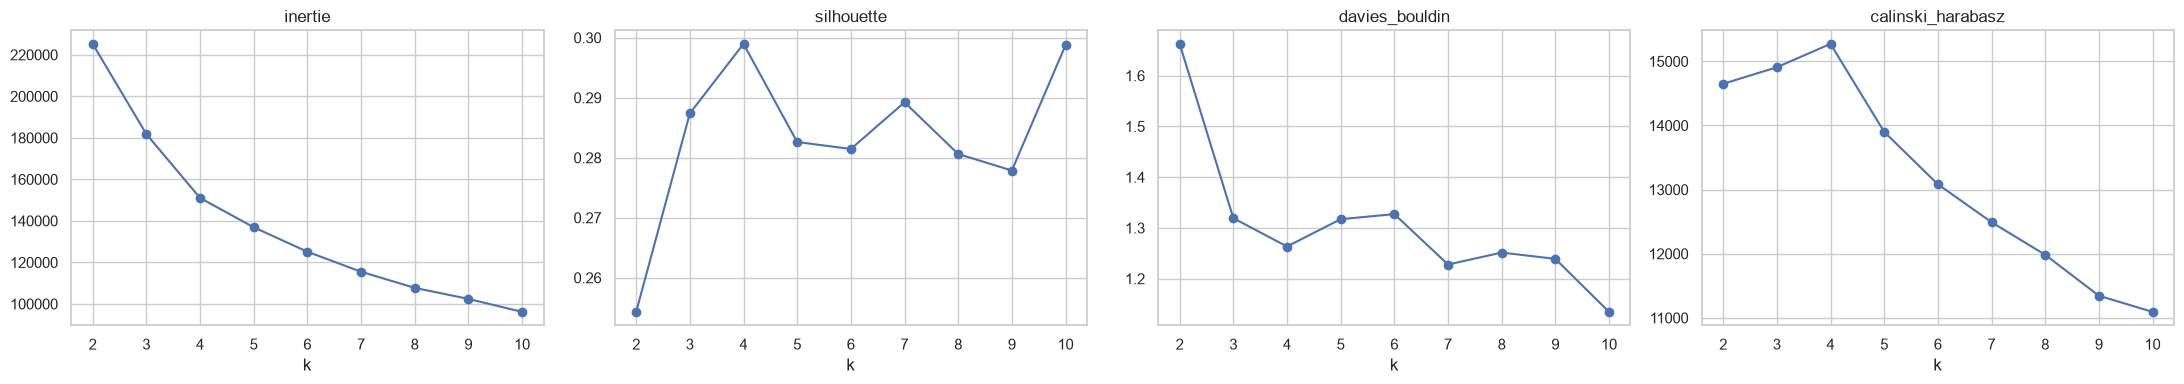

,inertie,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,225247.751,0.254,1.663,14649.051
3,181796.208,0.287,1.319,14907.603
4,151051.313,0.299,1.263,15272.251
5,136896.032,0.283,1.317,13900.371
6,125130.562,0.281,1.327,13083.063
7,115489.967,0.289,1.228,12491.509
8,107713.194,0.281,1.251,11982.976
9,102404.227,0.278,1.239,11344.749
10,96148.190,0.299,1.134,11092.900


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

SEG_FEATURES = ["age", "education-num", "hours_per_week_w", "log_capital_gain", "is_married", "sex_male"]
X_seg = StandardScaler().fit_transform(data[SEG_FEATURES])

rng = np.random.RandomState(RANDOM_STATE)
idx_s = rng.choice(len(X_seg), 8000, replace=False)   # échantillon pour la silhouette (coût O(n²))

res = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_seg)
    res.append([k, km.inertia_, silhouette_score(X_seg[idx_s], km.labels_[idx_s]),
                davies_bouldin_score(X_seg, km.labels_), calinski_harabasz_score(X_seg, km.labels_)])
res = pd.DataFrame(res, columns=["k", "inertie", "silhouette", "davies_bouldin", "calinski_harabasz"]).set_index("k")

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
for ax, c in zip(axes, res.columns):
    ax.plot(res.index, res[c], marker="o"); ax.set_title(c); ax.set_xlabel("k")
plt.tight_layout(); savefig("11_kmeans_choice_k"); plt.show()
res.round(3)

**Choix de k = 4 :**
- L'inertie diminue toujours quand k augmente, mais le **coude** se situe autour de k = 3–4 : au-delà, le gain par cluster supplémentaire devient faible.
- La **silhouette** atteint son maximum à k = 4 (≈ 0,30) parmi les petites valeurs de k. La valeur équivalente à k = 10 ne justifie pas de multiplier les segments : ils deviendraient difficiles à exploiter métier.
- **Calinski-Harabasz** est maximal à k = 4, et **Davies-Bouldin** y est faible (≈ 1,26).
- Quatre segments forment aussi un nombre **exploitable** pour des personas marketing ou de politique publique.

Une silhouette de ~0,30 indique des clusters de structure **modérée** : la population forme un continuum plutôt que des groupes parfaitement séparés, ce qui est attendu pour des données socio-démographiques.

In [30]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, n_init=20, random_state=RANDOM_STATE).fit(X_seg)
data["cluster"] = kmeans.labels_

print(f"k = {K_FINAL}")
print("Silhouette (échantillon) :", round(silhouette_score(X_seg[idx_s], kmeans.labels_[idx_s]), 3))
print("Davies-Bouldin           :", round(davies_bouldin_score(X_seg, kmeans.labels_), 3))
print("Calinski-Harabasz        :", round(calinski_harabasz_score(X_seg, kmeans.labels_), 1))

# Stabilité : comparaison avec une CAH (Ward) sur un échantillon
idx_h = rng.choice(len(X_seg), 6000, replace=False)
hc = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward").fit_predict(X_seg[idx_h])
print("ARI K-Means vs CAH Ward  :", round(adjusted_rand_score(kmeans.labels_[idx_h], hc), 3))

k = 4


Silhouette (échantillon) : 0.299
Davies-Bouldin           : 1.263
Calinski-Harabasz        : 15272.3


ARI K-Means vs CAH Ward  : 0.81


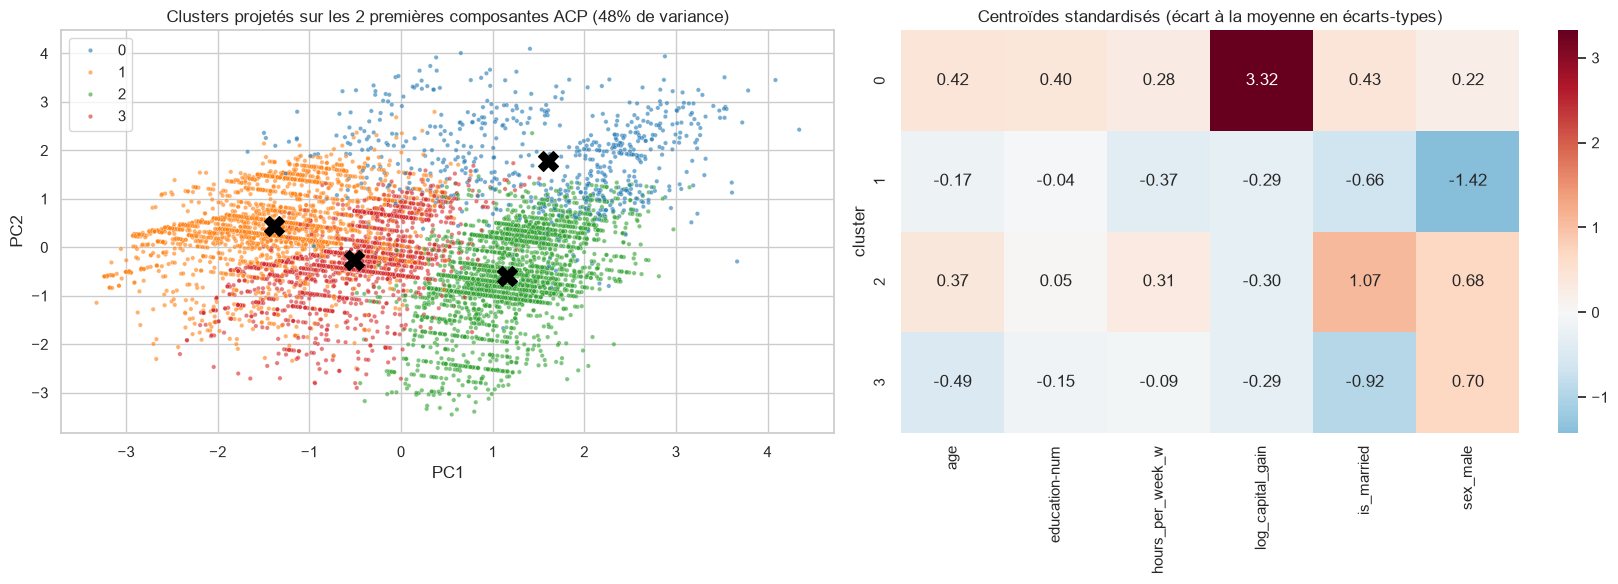

In [31]:
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_seg)
P = pca.transform(X_seg)
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.scatterplot(x=P[idx_s, 0], y=P[idx_s, 1], hue=data["cluster"].values[idx_s], palette="tab10",
                s=10, alpha=0.6, ax=axes[0])
C = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(C[:, 0], C[:, 1], c="black", marker="X", s=200)
axes[0].set_title(f"Clusters projetés sur les 2 premières composantes ACP "
                  f"({pca.explained_variance_ratio_.sum():.0%} de variance)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

centers = pd.DataFrame(kmeans.cluster_centers_, columns=SEG_FEATURES)
sns.heatmap(centers, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("Centroïdes standardisés (écart à la moyenne en écarts-types)")
axes[1].set_ylabel("cluster")
plt.tight_layout(); savefig("12_clusters_pca_centroids"); plt.show()

In [32]:
profile = data.groupby("cluster").agg(
    effectif=("age", "size"),
    age_moyen=("age", "mean"),
    education_num=("education-num", "mean"),
    heures=("hours-per-week", "mean"),
    pct_capital_gain=("has_capital_gain", "mean"),
    pct_marie=("is_married", "mean"),
    pct_homme=("sex_male", "mean"),
    taux_50K=("y", "mean"))
profile["part_%"] = profile["effectif"] / len(data) * 100
profile["occupation_principale"] = data.groupby("cluster")["occupation"].agg(lambda s: s.value_counts().index[0])
profile["relationship_principale"] = data.groupby("cluster")["relationship"].agg(lambda s: s.value_counts().index[0])
profile.round(2)

,effectif,age_moyen,education_num,heures,pct_capital_gain,pct_marie,pct_homme,taux_50K,part_%,occupation_principale,relationship_principale
cluster,,,,,,,,,,,
0,3977,44.40,11.11,43.82,1.0,0.68,0.77,0.63,8.15,Prof-specialty,Husband
1,15045,36.37,9.97,35.95,0.0,0.13,0.00,0.08,30.82,Adm-clerical,Not-in-family
2,17884,43.72,10.20,44.19,0.0,0.99,0.99,0.41,36.64,Craft-repair,Husband
3,11903,31.98,9.69,39.29,0.0,0.00,1.00,0.06,24.39,Craft-repair,Not-in-family


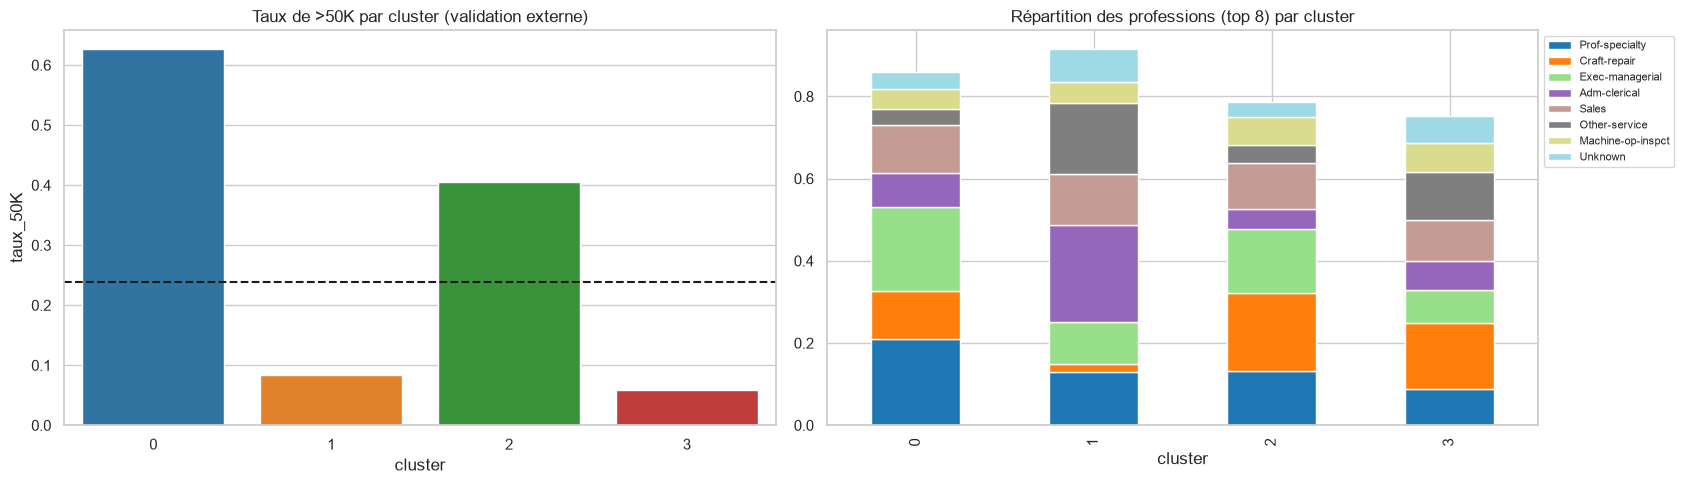

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.barplot(x=profile.index, y=profile["taux_50K"], ax=axes[0], palette="tab10")
axes[0].axhline(data["y"].mean(), ls="--", c="k"); axes[0].set_title("Taux de >50K par cluster (validation externe)")
occ = pd.crosstab(data["cluster"], data["occupation"], normalize="index")
top_occ = data["occupation"].value_counts().index[:8]
occ[top_occ].plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title("Répartition des professions (top 8) par cluster"); axes[1].legend(bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout(); savefig("13_cluster_profiles"); plt.show()

### 5.3 Interprétation des segments
| Cluster | Part | Profil | Taux >50K |
|---|---|---|---|
| **0 — « Détenteurs de capital »** | ~8 % | 100 % ont des plus-values en capital, ~44 ans, plus diplômés (education-num ≈ 11), 68 % mariés, surtout `Prof-specialty` | **~63 %** |
| **2 — « Hommes mariés, soutiens de famille »** | ~37 % | Hommes mariés (`Husband`), ~44 ans, ~44 h/semaine, métiers techniques/qualifiés (`Craft-repair`, `Exec-managerial`) | **~41 %** |
| **1 — « Femmes actives, majoritairement seules »** | ~31 % | 100 % femmes, ~36 ans, 13 % mariées, temps de travail plus court (~36 h), métiers administratifs (`Adm-clerical`) | **~8 %** |
| **3 — « Jeunes hommes célibataires »** | ~24 % | Hommes non mariés, ~32 ans, début de carrière | **~6 %** |

**Interprétation :**
- Le revenu **n'a pas été utilisé** pour construire les clusters, et pourtant les segments ont des taux de >50K très contrastés (de 6 % à 63 %). La segmentation capture donc une structure socio-économique réelle : **cycle de vie (âge, mariage) × patrimoine (capital) × temps de travail**.
- **Stabilité** : l'indice de Rand ajusté entre K-Means et une CAH de Ward vaut ≈ 0,81. Deux algorithmes différents retrouvent quasiment les mêmes groupes, donc les segments sont robustes.
- **Limite** : les variables binaires (`sex_male`, `is_married`, `log_capital_gain` très concentré en 0) structurent fortement la partition. C'est un effet connu de K-Means sur des données mixtes. Une variante avec K-Prototypes ou sans la variable `sex` serait une piste d'amélioration.
- **Usage métier** : le cluster 0 est la cible naturelle de produits d'épargne et d'investissement. Les clusters 1 et 3 (bas revenus, plus jeunes) relèvent plutôt de politiques de formation ou d'accès à l'emploi qualifié.

---
## 6. Classification

### 6.1 Problématique
Prédire si un individu gagne **plus de 50K $/an** (classification binaire supervisée).

### 6.2 Protocole expérimental
- **Découpage** : on respecte le split officiel UCI (train ≈ 2/3, test ≈ 1/3). Le **test n'est utilisé qu'une seule fois**, pour l'évaluation finale.
- **Sélection de modèles et d'hyperparamètres** : **validation croisée stratifiée à 5 plis** sur le train, qui conserve le ratio 76/24 dans chaque pli.
- **Pipelines** : la standardisation est apprise dans chaque pli, ce qui évite la fuite de données.
- **Modèles comparés** (vus en cours) :
  - *Dummy* (classe majoritaire) : référence minimale ;
  - **Régression logistique** : modèle linéaire interprétable, testé avec et sans `class_weight="balanced"` ;
  - **KNN** : modèle basé sur les distances ;
  - **Arbre de décision** : modèle interprétable, non linéaire ;
  - **Random Forest** : ensemble d'arbres (bagging), réduit la variance ;
  - **Gradient Boosting** (HistGradientBoosting) : ensemble séquentiel (boosting), souvent le plus performant sur données tabulaires.
- **Métriques** : accuracy, précision, rappel, **F1 (classe >50K)**, **ROC-AUC** et **PR-AUC** (adaptée au déséquilibre).

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay, classification_report)
from sklearn.inspection import permutation_importance

feat_cols = [c for c in prepared.columns if c not in ("income_gt_50K", "split")]
tr, te = prepared["split"] == "train", prepared["split"] == "test"
X_train, y_train = prepared.loc[tr, feat_cols], prepared.loc[tr, "income_gt_50K"]
X_test,  y_test  = prepared.loc[te, feat_cols], prepared.loc[te, "income_gt_50K"]
print("X_train", X_train.shape, "| X_test", X_test.shape)
print("Taux >50K train / test :", round(y_train.mean(), 3), "/", round(y_test.mean(), 3))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"accuracy": "accuracy", "precision": "precision", "recall": "recall",
           "f1": "f1", "roc_auc": "roc_auc", "pr_auc": "average_precision"}

X_train (32534, 52) | X_test (16275, 52)
Taux >50K train / test : 0.241 / 0.236


In [35]:
models = {
    "Dummy (majoritaire)": DummyClassifier(strategy="most_frequent"),
    "Régression logistique": Pipeline([("sc", StandardScaler()),
                                       ("clf", LogisticRegression(max_iter=2000))]),
    "Rég. logistique (balanced)": Pipeline([("sc", StandardScaler()),
                                            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "KNN (k=25)": Pipeline([("sc", StandardScaler()),
                            ("clf", KNeighborsClassifier(n_neighbors=25, n_jobs=-1))]),
    "Arbre de décision": DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3, n_jobs=-1,
                                            random_state=RANDOM_STATE),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv_rows = {}
for name, m in models.items():
    s = cross_validate(m, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=1)
    cv_rows[name] = {k: f"{s['test_'+k].mean():.3f} ± {s['test_'+k].std():.3f}" for k in SCORING}
cv_table = pd.DataFrame(cv_rows).T
cv_table

,accuracy,precision,recall,f1,roc_auc,pr_auc
Dummy (majoritaire),0.759 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000,0.241 ± 0.000
Régression logistique,0.855 ± 0.005,0.743 ± 0.013,0.607 ± 0.009,0.669 ± 0.010,0.910 ± 0.005,0.777 ± 0.013
Rég. logistique (balanced),0.813 ± 0.005,0.575 ± 0.007,0.850 ± 0.009,0.686 ± 0.007,0.910 ± 0.005,0.775 ± 0.013
KNN (k=25),0.838 ± 0.005,0.691 ± 0.014,0.594 ± 0.009,0.639 ± 0.010,0.886 ± 0.005,0.703 ± 0.014
Arbre de décision,0.855 ± 0.004,0.794 ± 0.016,0.540 ± 0.013,0.643 ± 0.011,0.905 ± 0.004,0.761 ± 0.007
Random Forest,0.866 ± 0.006,0.779 ± 0.017,0.620 ± 0.015,0.690 ± 0.015,0.919 ± 0.005,0.810 ± 0.012
Gradient Boosting,0.872 ± 0.005,0.776 ± 0.015,0.659 ± 0.011,0.712 ± 0.010,0.928 ± 0.004,0.828 ± 0.010


**Lecture de la validation croisée :**
- Tous les modèles battent largement la référence *Dummy* (accuracy 0,76 mais F1 = 0 : elle ne détecte **aucun** individu >50K). Cela confirme que l'accuracy seule est trompeuse.
- La **régression logistique** atteint déjà un ROC-AUC de 0,91 : la préparation (log des capitaux, one-hot, regroupements) rend le problème en grande partie linéairement séparable.
- `class_weight="balanced"` fait passer le rappel de 0,61 à 0,85 au prix de la précision (0,74 → 0,58). C'est le compromis précision/rappel classique en données déséquilibrées.
- **KNN** est le moins bon des modèles non triviaux : avec ~50 dimensions dont beaucoup de binaires, la notion de distance devient moins informative (malédiction de la dimension).
- Les méthodes d'ensemble dominent : **Gradient Boosting** (ROC-AUC 0,928, F1 0,71) > Random Forest (0,919) > arbre seul (0,905).

### 6.3 Optimisation des hyperparamètres
On optimise les deux meilleurs modèles d'ensemble par **GridSearchCV** (5 plis stratifiés), en maximisant le **ROC-AUC**. C'est une métrique indépendante du seuil, que l'on ajustera ensuite séparément. On optimise aussi la profondeur de l'arbre de décision pour obtenir un modèle interprétable de bonne qualité.

In [36]:
grids = {
    "Arbre de décision": (DecisionTreeClassifier(random_state=RANDOM_STATE),
                          {"max_depth": [4, 6, 8, 10, 12], "min_samples_leaf": [5, 20, 50]}),
    "Random Forest": (RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
                      {"max_depth": [12, 20, None], "min_samples_leaf": [1, 3, 5], "max_features": ["sqrt", 0.3]}),
    "Gradient Boosting": (HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                          {"learning_rate": [0.05, 0.1], "max_leaf_nodes": [15, 31, 63],
                           "l2_regularization": [0.0, 1.0]}),
}
best = {}
for name, (est, grid) in grids.items():
    gs = GridSearchCV(est, grid, cv=cv, scoring="roc_auc", n_jobs=-1).fit(X_train, y_train)
    best[name] = gs.best_estimator_
    print(f"{name:20s} ROC-AUC CV = {gs.best_score_:.4f} | {gs.best_params_}")

Arbre de décision    ROC-AUC CV = 0.9073 | {'max_depth': 12, 'min_samples_leaf': 50}


Random Forest        ROC-AUC CV = 0.9208 | {'max_depth': 12, 'max_features': 0.3, 'min_samples_leaf': 1}


Gradient Boosting    ROC-AUC CV = 0.9279 | {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_leaf_nodes': 31}


### 6.4 Ajustement du seuil de décision
Par défaut, un classifieur prédit >50K si P(>50K) ≥ 0,5. Avec des classes déséquilibrées, ce seuil n'est pas optimal pour le F1 de la classe minoritaire. On choisit le seuil qui **maximise le F1 sur des prédictions out-of-fold du train** (`cross_val_predict`), **jamais sur le test**, pour que l'évaluation finale reste honnête.

In [37]:
final_models = {
    "Régression logistique": models["Régression logistique"],
    "KNN (k=25)": models["KNN (k=25)"],
    "Arbre de décision (optimisé)": best["Arbre de décision"],
    "Random Forest (optimisé)": best["Random Forest"],
    "Gradient Boosting (optimisé)": best["Gradient Boosting"],
}
thresholds = {}
for name, m in final_models.items():
    oof = cross_val_predict(m, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    grid_t = np.arange(0.2, 0.71, 0.01)
    f1s = [f1_score(y_train, oof >= t) for t in grid_t]
    thresholds[name] = grid_t[int(np.argmax(f1s))]
    print(f"{name:30s} seuil optimal = {thresholds[name]:.2f} (F1 OOF = {max(f1s):.3f} vs {f1_score(y_train, oof >= 0.5):.3f} à 0,5)")

Régression logistique          seuil optimal = 0.35 (F1 OOF = 0.695 vs 0.669 à 0,5)


KNN (k=25)                     seuil optimal = 0.32 (F1 OOF = 0.671 vs 0.640 à 0,5)


Arbre de décision (optimisé)   seuil optimal = 0.36 (F1 OOF = 0.696 vs 0.659 à 0,5)


Random Forest (optimisé)       seuil optimal = 0.40 (F1 OOF = 0.719 vs 0.677 à 0,5)


Gradient Boosting (optimisé)   seuil optimal = 0.35 (F1 OOF = 0.730 vs 0.712 à 0,5)


### 6.5 Évaluation finale sur le jeu de test

In [38]:
rows, probas = [], {}
for name, m in final_models.items():
    m.fit(X_train, y_train)
    p = m.predict_proba(X_test)[:, 1]; probas[name] = p
    for label, t in [("seuil 0,5", 0.5), ("seuil optimisé", thresholds[name])]:
        pred = (p >= t).astype(int)
        rows.append([name, label, round(t, 2), accuracy_score(y_test, pred), precision_score(y_test, pred),
                     recall_score(y_test, pred), f1_score(y_test, pred),
                     roc_auc_score(y_test, p), average_precision_score(y_test, p)])
dummy_acc = (y_test == 0).mean()
test_table = pd.DataFrame(rows, columns=["modèle", "seuil", "t", "accuracy", "precision", "recall",
                                         "f1", "roc_auc", "pr_auc"]).set_index(["modèle", "seuil"]).round(3)
print(f"Référence Dummy : accuracy = {dummy_acc:.3f}, F1 = 0, ROC-AUC = 0,5")
test_table

Référence Dummy : accuracy = 0.764, F1 = 0, ROC-AUC = 0,5


t  accuracy  precision  recall     f1  roc_auc  pr_auc
modèle                       seuil                                                                    
Régression logistique        seuil 0,5       0.50     0.855      0.735   0.602  0.662    0.907   0.770
                             seuil optimisé  0.35     0.841      0.643   0.738  0.687    0.907   0.770
KNN (k=25)                   seuil 0,5       0.50     0.838      0.678   0.598  0.635    0.884   0.695
                             seuil optimisé  0.32     0.816      0.585   0.757  0.660    0.884   0.695
Arbre de décision (optimisé) seuil 0,5       0.50     0.860      0.777   0.572  0.659    0.907   0.782
                             seuil optimisé  0.36     0.848      0.670   0.701  0.685    0.907   0.782
Random Forest (optimisé)     seuil 0,5       0.50     0.867      0.799   0.585  0.675    0.920   0.810
                             seuil optimisé  0.40     0.864      0.720   0.696  0.708    0.920   0.810
Gradient Boosting (optimisé) seuil 0,5       0.50     0.872      0.771   0.653  0.707    0.928   0.827
                             seuil optimisé  0.35     0.858      0.671   0.785  0.723    0.928   0.827

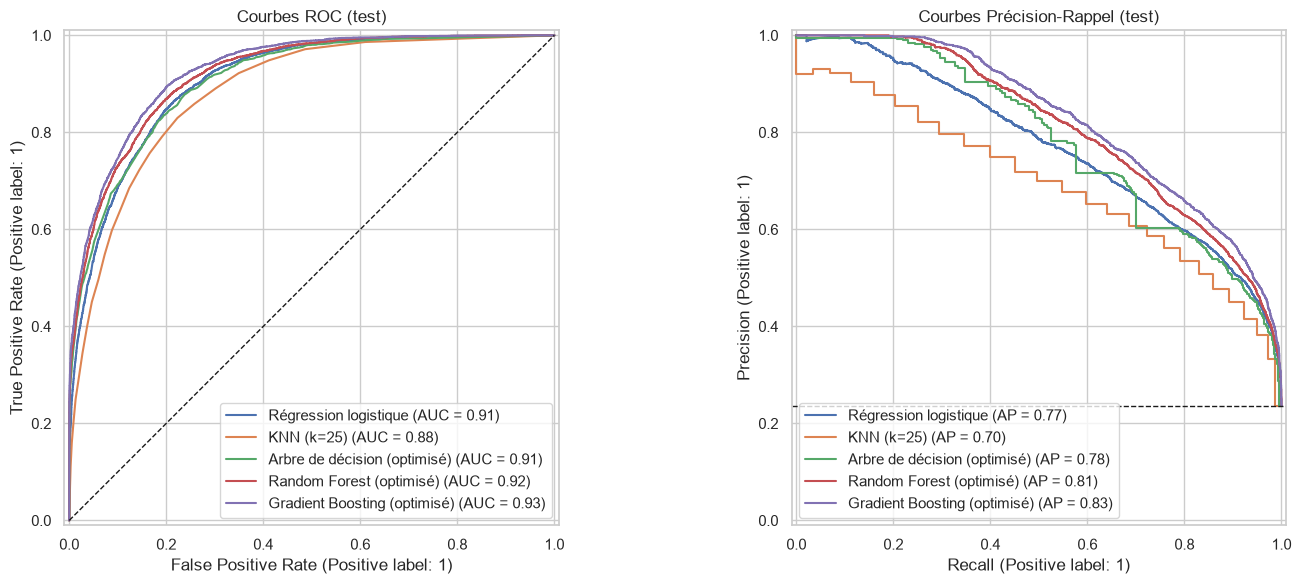

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for name, p in probas.items():
    RocCurveDisplay.from_predictions(y_test, p, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, p, name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], "k--", lw=1); axes[0].set_title("Courbes ROC (test)")
axes[1].axhline(y_test.mean(), ls="--", c="k", lw=1); axes[1].set_title("Courbes Précision-Rappel (test)")
plt.tight_layout(); savefig("14_roc_pr"); plt.show()

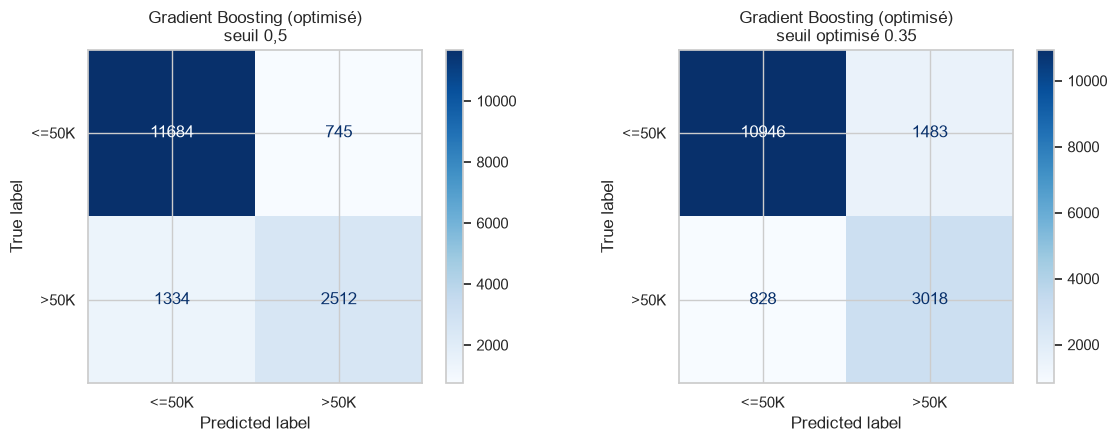

              precision    recall  f1-score   support

       <=50K      0.930     0.881     0.905     12429
        >50K      0.671     0.785     0.723      3846

    accuracy                          0.858     16275
   macro avg      0.800     0.833     0.814     16275
weighted avg      0.868     0.858     0.862     16275



In [40]:
BEST = "Gradient Boosting (optimisé)"
best_model, t_best = final_models[BEST], thresholds[BEST]
pred_best = (probas[BEST] >= t_best).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, (probas[BEST] >= 0.5).astype(int), display_labels=["<=50K", ">50K"],
                                        cmap="Blues", ax=axes[0], values_format="d")
axes[0].set_title(f"{BEST}\nseuil 0,5")
ConfusionMatrixDisplay.from_predictions(y_test, pred_best, display_labels=["<=50K", ">50K"],
                                        cmap="Blues", ax=axes[1], values_format="d")
axes[1].set_title(f"{BEST}\nseuil optimisé {t_best:.2f}")
plt.tight_layout(); savefig("15_confusion_matrix"); plt.show()

print(classification_report(y_test, pred_best, target_names=["<=50K", ">50K"], digits=3))

### 6.6 Interprétabilité

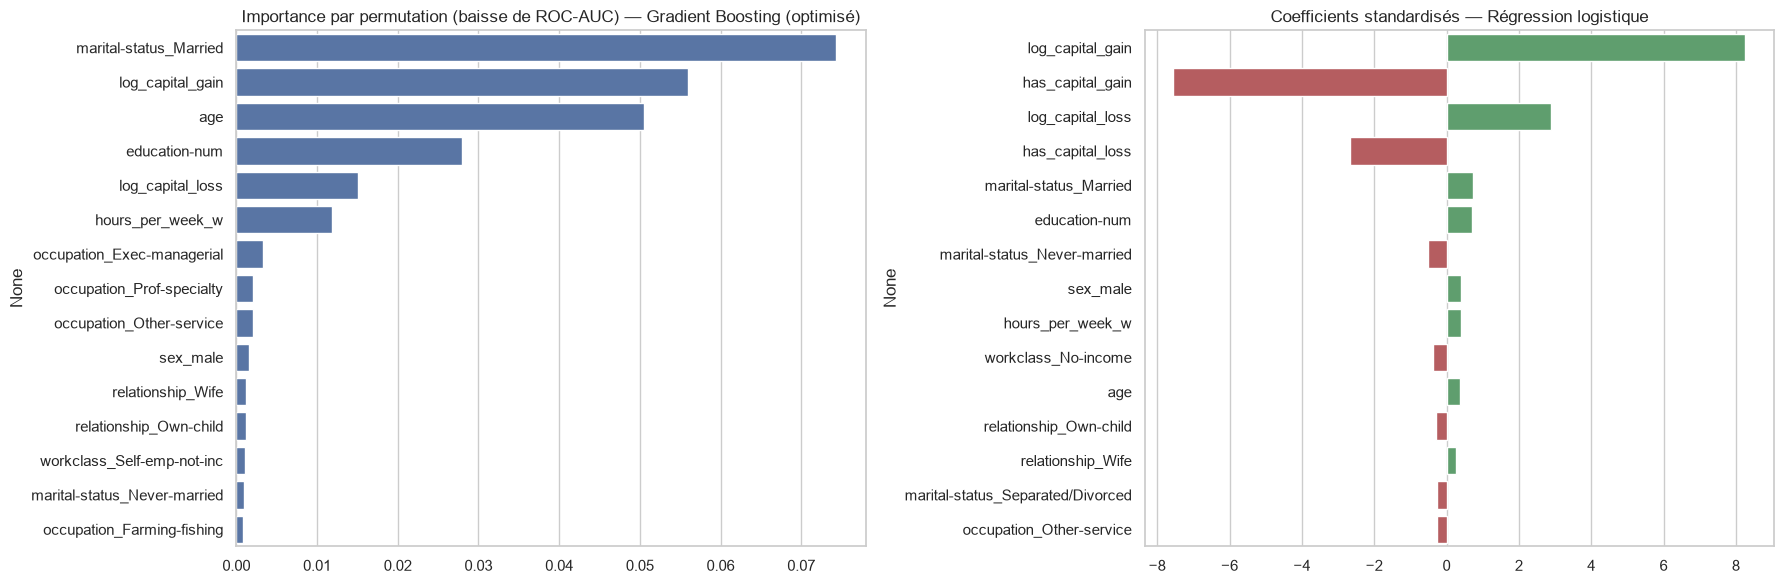

In [41]:
pi = permutation_importance(best_model, X_test, y_test, scoring="roc_auc", n_repeats=5,
                            random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=feat_cols).sort_values(ascending=False).head(15)

lr = final_models["Régression logistique"]
coef = pd.Series(lr.named_steps["clf"].coef_[0], index=feat_cols)
coef = coef.reindex(coef.abs().sort_values(ascending=False).index).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(x=imp.values, y=imp.index, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"Importance par permutation (baisse de ROC-AUC) — {BEST}")
sns.barplot(x=coef.values, y=coef.index, ax=axes[1],
            palette=["#C44E52" if v < 0 else "#55A868" for v in coef.values])
axes[1].set_title("Coefficients standardisés — Régression logistique")
plt.tight_layout(); savefig("16_feature_importance"); plt.show()

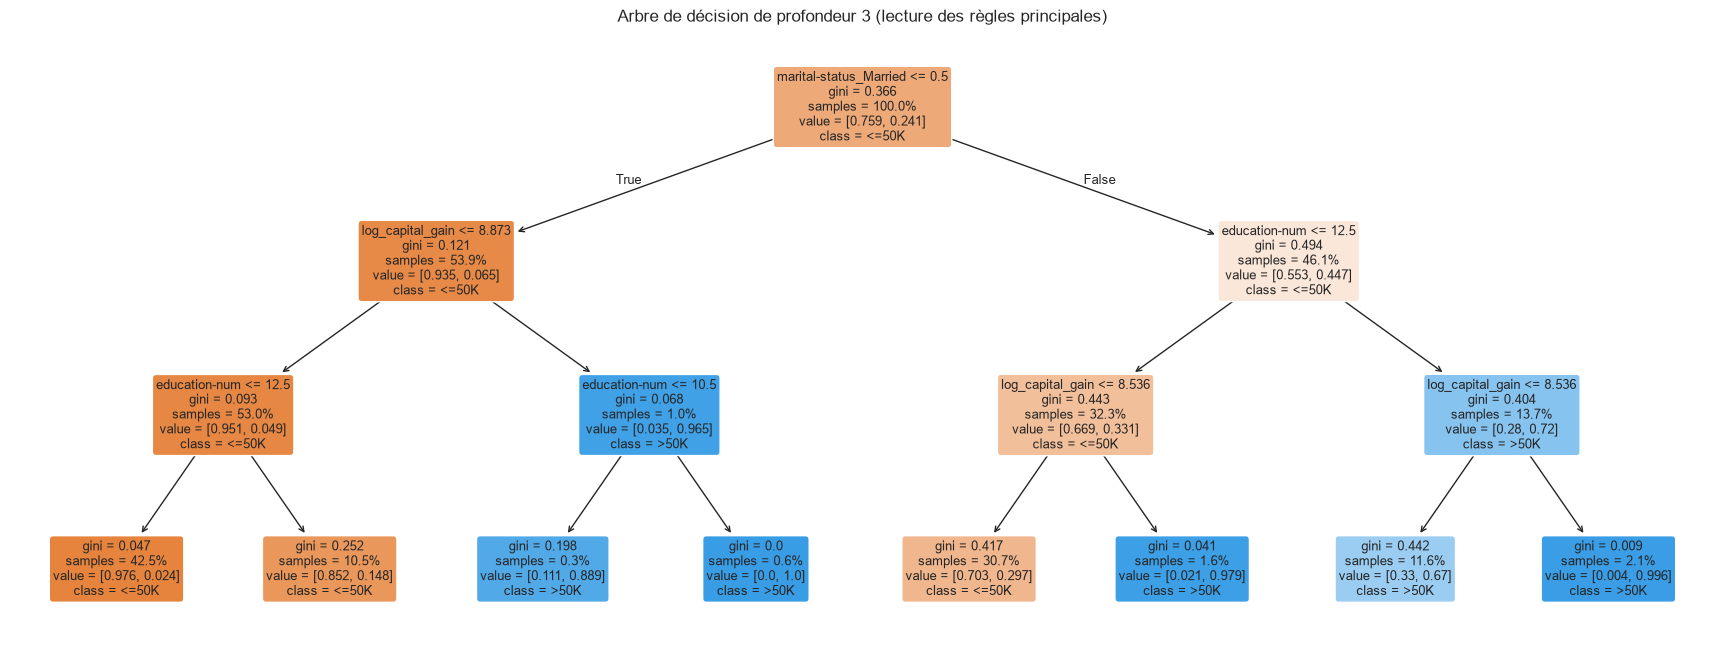

In [42]:
small_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=RANDOM_STATE).fit(X_train, y_train)
plt.figure(figsize=(22, 8))
plot_tree(small_tree, feature_names=feat_cols, class_names=["<=50K", ">50K"], filled=True,
          rounded=True, proportion=True, fontsize=9)
plt.title("Arbre de décision de profondeur 3 (lecture des règles principales)")
savefig("17_decision_tree"); plt.show()

### 6.7 Analyse d'équité (attribut sensible `sex`)

In [43]:
sex_test = data.loc[data["split"] == "test", "sex"].values
fair = []
for g in ["Male", "Female"]:
    mk = sex_test == g
    fair.append([g, mk.sum(), y_test[mk].mean(), pred_best[mk].mean(),
                 precision_score(y_test[mk], pred_best[mk]), recall_score(y_test[mk], pred_best[mk])])
pd.DataFrame(fair, columns=["sexe", "effectif", "taux réel >50K", "taux prédit >50K",
                            "précision", "rappel"]).set_index("sexe").round(3)

,effectif,taux réel >50K,taux prédit >50K,précision,rappel
sexe,,,,,
Male,10855,0.300,0.357,0.671,0.799
Female,5420,0.109,0.115,0.670,0.708


---
## 7. Évaluation, interprétation et conclusion

### 7.1 Synthèse des performances (jeu de test, jamais utilisé pour l'entraînement ni les réglages)

| Modèle | Accuracy | F1 (>50K) | ROC-AUC | PR-AUC |
|---|---|---|---|---|
| Dummy (majoritaire) | 0,764 | 0,000 | 0,500 | 0,236 |
| Régression logistique (seuil 0,35) | 0,841 | 0,687 | 0,907 | 0,770 |
| KNN k=25 (seuil 0,32) | 0,816 | 0,660 | 0,884 | 0,695 |
| Arbre de décision optimisé (seuil 0,36) | 0,848 | 0,685 | 0,907 | 0,782 |
| Random Forest optimisé (seuil 0,40) | 0,864 | 0,708 | 0,920 | 0,810 |
| **Gradient Boosting optimisé (seuil 0,35)** | **0,858** | **0,723** | **0,928** | **0,827** |

- **Modèle retenu : Gradient Boosting**, meilleur sur toutes les métriques indépendantes du seuil (ROC-AUC 0,928, PR-AUC 0,827) et sur le F1. Les scores de test sont très proches des scores de validation croisée : **pas de sur-apprentissage**, et l'estimation est fiable.
- **Effet du seuil** : passer de 0,5 à 0,35 fait monter le rappel de la classe >50K de 0,65 à **0,79** (précision 0,77 → 0,67) et le F1 de 0,707 à 0,723. L'accuracy baisse légèrement, ce qui est normal : elle favorise la classe majoritaire. Le seuil est un **levier métier**. Une banque qui ne veut rater aucun prospect aisé choisira un seuil bas ; une campagne coûteuse choisira un seuil haut (plus de précision).
- Les objectifs fixés en Business Understanding sont atteints : ROC-AUC ≥ 0,90 et F1 très supérieur au modèle naïf.

### 7.2 Facteurs explicatifs du revenu
L'importance par permutation du Gradient Boosting et l'arbre de profondeur 3 convergent :
1. **Être marié** (`marital-status_Married`) est le facteur n°1. Il reflète à la fois un effet d'âge/stabilité et le fait que la variable mesure le revenu *du foyer déclaré par l'individu*.
2. **Les gains en capital** (`log_capital_gain`) : marqueur direct de patrimoine.
3. **L'âge**, puis le **niveau d'études** (`education-num`), les pertes en capital et les **heures travaillées**.
4. Les professions `Exec-managerial` / `Prof-specialty` viennent ensuite.

*Remarque sur la régression logistique :* `log_capital_gain` et `has_capital_gain` sont très corrélées (coefficients de signes opposés qui se compensent). Leurs coefficients ne doivent pas être lus isolément ; c'est leur **effet conjoint** qui est positif.

### 7.3 Équité
Le sexe a une importance directe faible dans le modèle, mais le **rappel est plus faible pour les femmes (≈ 0,71) que pour les hommes (≈ 0,80)** à précision égale (≈ 0,67). Le modèle rate donc davantage de femmes à haut revenu. Le biais passe aussi indirectement par des variables corrélées (`relationship` = `Husband`/`Wife`, occupation, heures). Avant tout usage décisionnel réel (crédit, aides), il faudrait un audit d'équité, éventuellement un seuil par groupe ou un retrait des variables proxy.

### 7.4 Apport de la préparation des données
- Les valeurs manquantes traitées comme modalité `Unknown` conservent un signal réel : taux de >50K de 9,5 % contre 24,8 %.
- La transformation log des capitaux et la winsorisation rendent les modèles linéaires et à distance compétitifs (ROC-AUC 0,91 pour la régression logistique).
- Les regroupements de modalités font passer de 100+ colonnes one-hot potentielles à **52 features**, sans perte de performance.
- La suppression de `fnlwgt` et d'`education` retire du bruit et de la redondance.
- La discipline anti-fuite (split officiel, scaler et seuils appris sur le train, test utilisé une seule fois) garantit que les scores reportés sont honnêtes.

### 7.5 Limites et perspectives
- Données de **1994** : les seuils de revenu et la structure du marché du travail ont changé ; le modèle ne doit pas être appliqué tel quel aujourd'hui.
- Seuil de 50K binaire : une régression sur le revenu réel serait plus informative, mais la donnée n'est pas disponible.
- Pistes : K-Prototypes pour la segmentation mixte, calibration des probabilités, SHAP pour une explicabilité individuelle, rééchantillonnage (SMOTE) comparé à la pondération des classes.